# 🌿 PLANesT-3D — Utonia (frozen SSL encoder) vs. Point Transformer V3 (supervised)
### Plant: `Ribes_04` — cross-domain self-supervised pretraining vs. from-scratch supervised training, evaluated on GT + every noisy variant

This notebook is a **sibling of** `PLANesT3D_PointTransformerV3_Degradation_Robustness.ipynb`, not a
replacement. It reuses that notebook's already-trained checkpoint (`robustness_eval_ptv3/checkpoints/ptv3_best.pth`)
for the **`Z_P`** branch, and adds a second branch, **`Z_U`**, built the same way Utonia is actually meant
to be used:

```
                       Ribes_04 GT
                            │
              ┌─────────────┴─────────────┐
              │                            │
              ▼                            ▼
        PTv3 (supervised,             Utonia-Lite (self-supervised
        trained end-to-end               pretrained on unlabeled
        on GT labels)                    GT geometry, then FROZEN)
              │                            │
              ▼                            ▼
             Z_P                          Z_U
              │                            │
              ▼                            ▼
        segmentation head           linear-probe segmentation head
        (trained jointly)           (only head trained, encoder frozen)
              │                            │
              └─────────────┬──────────────┘
                             ▼
                          compare
                             │
                     GT  vs.  noisy (manifest.csv)
                             │
                             ▼
                    robustness analysis (ΔmIoU, degradation %)
```

**About Utonia — please read, this matters for interpreting the results:** the official
[Utonia](https://github.com/Pointcept/Utonia) (Zhang et al., ICML'26) is a 137M-parameter Point
Transformer V3 pretrained with masked self-distillation across five heterogeneous point-cloud domains
(remote sensing, outdoor LiDAR, indoor RGB-D, object CAD, video-lifted scans). Its released weights are
loaded through the **Pointcept** codebase, which pulls in `spconv` + `flash-attention` custom CUDA
kernels — precisely the fragile, version-sensitive dependency chain the PTv3 notebook in this pipeline
already went out of its way to avoid on a stock Colab runtime.

So, **same policy as the PTv3 notebook**: this is a faithful **"Lite" reimplementation** of what makes
Utonia *Utonia* — not just a checkpoint swap:

- **Self-supervised pretraining, not supervised training.** The encoder never sees `SemanticLabels.txt`
  during pretraining. It is trained with a **masked reconstruction pretext task** on the unlabeled GT
  geometry: a random subset of points has its input features masked out (color, if available — or the
  points themselves are corrupted with coordinate noise, if not), and the encoder + a small pretext head
  must reconstruct the missing information from context. This is the same family of objective Utonia's
  paper describes ("masks out random patches, then tries to reconstruct the masked points' positions and
  features").
- **Frozen encoder + linear-probe head**, exactly how Utonia is used in practice: after pretraining, the
  encoder's weights are **frozen** (`requires_grad = False`) and only a lightweight segmentation head is
  trained on top, using the same GT labels / train-val split as the PTv3 branch. `Z_P` is a fully
  fine-tuned model; `Z_U` is a frozen general-purpose representation with a thin task head — that
  asymmetry is the whole point of the comparison.
- Same serialized/windowed-attention U-Net building blocks as the PTv3 notebook (Morton-order
  serialization, patch attention, serialized pooling, inverse-distance-weighted feature propagation) —
  pure PyTorch, no `spconv`, no `flash-attn`, nothing that can silently fail on a GPU-architecture
  mismatch in Colab.

**Scope — same as the other notebook:** no COLMAP anywhere here. Robustness is measured the same way as
the PTv3 notebook: one frozen-after-training model per branch, evaluated once on clean GT and once on
every `(category, level)` noisy variant already generated by `PLANesT3D_Degradation_Pipeline.ipynb`
(`manifest.csv`). If a COLMAP reconstruction pipeline is ever added to this project, it would show up in
the same `manifest.csv` as just another variant category — nothing in this notebook needs to change.

**What this notebook saves — metrics & figures only, no `.ply` files, into a *new* `utonia/` folder next
to `robustness_eval_ptv3/` so both branches' summary tables can be concatenated side by side:**

- `utonia/checkpoints/ptv3_supervised.pth` — copy of / pointer to the PTv3 checkpoint actually used for `Z_P`
- `utonia/checkpoints/utonia_lite_encoder.pth` — the self-supervised pretrained, frozen encoder
- `utonia/checkpoints/utonia_lite_probe.pth` — the trained segmentation probe head (best val mIoU)
- `utonia/tables/ssl_pretrain_history.csv`, `utonia/tables/probe_train_history.csv`
- `utonia/tables/gt_baseline_metrics_ptv3.json`, `utonia/tables/gt_baseline_metrics_utonia.json`
- `utonia/tables/variant_metrics.csv` / `.json` — **both models**, one row per `(model, category, level)`
- `utonia/tables/summary_degradation_table.csv` — `Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation %`
- `utonia/tables/confusion_matrices/*.npy` — raw confusion matrix per (model, variant) + per-model GT
- `utonia/figures/*.png` — SSL + probe training curves, GT confusion matrices side by side, per-class IoU
  comparison, mIoU-vs-severity per category (one line per model), degradation-% heatmaps, per-class IoU
  degradation curves, confusion-matrix grid, and a **robustness-gap** chart (frozen SSL vs. fully
  supervised)
- `utonia/report/utonia_vs_ptv3_report.md` — auto-written summary, ready to paste into slides

> Runtime: **GPU strongly recommended** (Colab: `Runtime → Change runtime type → T4 GPU`). SSL
> pretraining + probe training + evaluating two models roughly doubles the PTv3 notebook's runtime.


## 1. Setup — install dependencies

In [1]:
!pip install -q open3d plyfile scikit-learn pandas numpy matplotlib seaborn tqdm
print("Dependencies ready. (Pure PyTorch — no spconv / flash-attn / custom CUDA kernels, no Pointcept, "
      "no download of the real Utonia weights needed.)")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.5 MB/s eta 0:00:00
Dependencies ready. (Pure PyTorch — no spconv / flash-attn / custom CUDA kernels, no Pointcept, no download of the real Utonia weights needed.)


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Configuration — paths (GT, noisy manifest, existing PTv3 checkpoint, new `utonia/` outputs)

In [4]:
import os

# --- Dataset location -------------------------------------------------------
BASE_DIR   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
PLANT_NAME = "Ribes_04"

# GT reconstruction folder (read-only — same convention as the other notebooks)
GT_DIR = os.path.join(BASE_DIR, "gt_reconstruction")

PLY_PATH        = os.path.join(GT_DIR, f"{PLANT_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{PLANT_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{PLANT_NAME}_Confidence.txt")

# Noisy / degraded reconstructions + manifest, produced by the Degradation Pipeline notebook
NOISY_DIR      = os.path.join(BASE_DIR, "noisy_reconstruction")
DEGRADED_DIR   = os.path.join(NOISY_DIR, "degraded")
MANIFEST_PATH  = os.path.join(DEGRADED_DIR, "manifest.csv")

# --- Existing, already-trained PTv3 checkpoint (from the sibling notebook) --
PTV3_ROBUST_DIR   = os.path.join(BASE_DIR, "outputs", PLANT_NAME, "robustness_eval_ptv3")
PTV3_CKPT_PATH    = os.path.join(PTV3_ROBUST_DIR, "checkpoints", "ptv3_best.pth")

# --- Output location (auto-created) — metrics & figures ONLY, never .ply ----
OUTPUT_DIR   = os.path.join(BASE_DIR, "outputs", PLANT_NAME)
ROBUST_DIR   = os.path.join(OUTPUT_DIR, "utonia")           # <-- new folder, this notebook's own space
FIG_DIR      = os.path.join(ROBUST_DIR, "figures")
METRICS_DIR  = os.path.join(ROBUST_DIR, "tables")
CM_DIR       = os.path.join(METRICS_DIR, "confusion_matrices")
REPORT_DIR   = os.path.join(ROBUST_DIR, "report")
CKPT_DIR     = os.path.join(ROBUST_DIR, "checkpoints")

for d in [ROBUST_DIR ,FIG_DIR, METRICS_DIR, CM_DIR, REPORT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Semantic class legend --------------------------------------------------
SEMANTIC_CLASS_NAMES = {
    0: "Background / Pot / Soil",
    1: "Stem",
    2: "Leaf",
}
NUM_CLASSES = len(SEMANTIC_CLASS_NAMES)

RANDOM_SEED = 42

print("GT folder        :", GT_DIR)
print("Manifest         :", MANIFEST_PATH)
print("Existing PTv3 ckpt:", PTV3_CKPT_PATH, "->", "FOUND" if os.path.exists(PTV3_CKPT_PATH) else "NOT FOUND (will train a fresh fallback)")
print("Utonia outputs    :", ROBUST_DIR)
print("  figures   ->", FIG_DIR)
print("  tables    ->", METRICS_DIR)
print("  report    ->", REPORT_DIR)
print("  checkpts  ->", CKPT_DIR)


GT folder        : /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction
Manifest         : /content/drive/MyDrive/segmentation_jetcobot_internship/noisy_reconstruction/degraded/manifest.csv
Existing PTv3 ckpt: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/robustness_eval_ptv3/checkpoints/ptv3_best.pth -> FOUND
Utonia outputs    : /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia
  figures   -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia/figures
  tables    -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia/tables
  report    -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia/report
  checkpts  -> /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia/checkpoints


## 3. Hyperparameters

The architecture hyperparameters below are only the **defaults** used if `PTV3_CKPT_PATH` is missing and
this notebook has to train a fresh PTv3 fallback. If the checkpoint is found, its own saved architecture
(embedded in the `.pth` by the sibling notebook) is used instead, so the loaded weights always match — see
Section 9. The **same** architecture family is used for the Utonia-Lite branch, so the two branches are
comparable at matched capacity; only the *pretraining recipe* differs.

In [5]:
import numpy as np

# --- Model input --------------------------------------------------------------
N_POINTS_PER_SAMPLE = 4096   # points per training crop AND per eval chunk (must be >= 1024)
USE_RGB_FEATURES    = True   # use RGB as extra per-point features if the GT .ply has color
ADDITIONAL_CHANNELS = 3 if USE_RGB_FEATURES else 0

# --- Point Transformer V3 (Lite) architecture — fallback defaults -------------
STAGE_CHANNELS = (64, 128, 256, 512)   # per-stage feature width (encoder, mirrored in decoder)
STAGE_DEPTHS   = (2, 2, 2, 2)          # serialized-attention Transformer blocks per stage
NUM_HEADS      = 4                     # attention heads (must evenly divide every stage width)
PATCH_SIZE     = 32                    # windowed/serialized attention patch size (points/window)
POOL_RATIO     = 4                     # spatial downsampling ratio between stages
GRID_RES       = 1024                  # Morton-code voxel grid resolution used for serialization
DROPOUT        = 0.1

# --- Supervised PTv3 fallback training (only used if no checkpoint is found) --
EPOCHS                    = 40
BATCH_SIZE                = 8
LEARNING_RATE             = 1e-3
LR_DECAY_STEP             = 15
LR_DECAY_GAMMA            = 0.5
WEIGHT_DECAY               = 1e-4

# --- Utonia-Lite self-supervised pretraining -----------------------------------
SSL_MASK_RATIO       = 0.30    # fraction of points masked per crop during SSL pretraining
SSL_EPOCHS            = 40
SSL_BATCH_SIZE         = 8
SSL_LEARNING_RATE       = 1e-3
SSL_N_SAMPLES_PER_EPOCH = 300   # random unlabeled crops drawn per SSL epoch (whole GT cloud, no split needed)

# --- Utonia-Lite linear-probe segmentation head (encoder frozen) --------------
PROBE_EPOCHS       = 40
PROBE_BATCH_SIZE   = 8
PROBE_LEARNING_RATE = 1e-3
PROBE_LR_DECAY_STEP  = 15
PROBE_LR_DECAY_GAMMA = 0.5
PROBE_WEIGHT_DECAY   = 1e-4

# --- Shared train/val point-level split of the single GT cloud ----------------
N_TRAIN_SAMPLES_PER_EPOCH = 300   # random crops drawn from the GT "train" point pool per epoch
N_VAL_SAMPLES_PER_EPOCH   = 60    # random crops drawn from the GT "val" point pool per epoch
TRAIN_POINT_FRACTION      = 0.85  # point-level split of the single GT cloud (see note in Section 7)

# --- Whole-cloud evaluation (GT + every noisy variant) ------------------------
N_REPEATS_EVAL = 4    # number of full-coverage passes averaged together per cloud

# --- Misc -----------------------------------------------------------------------
np.random.seed(RANDOM_SEED)
assert all(c % NUM_HEADS == 0 for c in STAGE_CHANNELS), "STAGE_CHANNELS must all be divisible by NUM_HEADS"
print(f"N_POINTS_PER_SAMPLE = {N_POINTS_PER_SAMPLE}, ADDITIONAL_CHANNELS = {ADDITIONAL_CHANNELS}")
print(f"STAGE_CHANNELS = {STAGE_CHANNELS}, STAGE_DEPTHS = {STAGE_DEPTHS}, PATCH_SIZE = {PATCH_SIZE}, POOL_RATIO = {POOL_RATIO}")
print(f"SSL: mask_ratio={SSL_MASK_RATIO}, epochs={SSL_EPOCHS}  |  Probe: epochs={PROBE_EPOCHS}  |  Fallback supervised: epochs={EPOCHS}")


N_POINTS_PER_SAMPLE = 4096, ADDITIONAL_CHANNELS = 3
STAGE_CHANNELS = (64, 128, 256, 512), STAGE_DEPTHS = (2, 2, 2, 2), PATCH_SIZE = 32, POOL_RATIO = 4
SSL: mask_ratio=0.3, epochs=40  |  Probe: epochs=40  |  Fallback supervised: epochs=40


## 4. Device

In [6]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu":
    print("⚠️  No GPU detected — training will be slow. In Colab: Runtime > Change runtime type > GPU.")
else:
    print("Using GPU:", torch.cuda.get_device_name(0))


Using GPU: Tesla T4


## 5. Load the clean GT point cloud (read-only, never modified)

In [7]:
import open3d as o3d

def load_point_cloud(path):
    pcd = o3d.io.read_point_cloud(path)
    pts = np.asarray(pcd.points, dtype=np.float64)
    cols = np.asarray(pcd.colors, dtype=np.float64) if pcd.has_colors() else None
    return pts, cols

def load_label_file(path, dtype=np.int64):
    return np.loadtxt(path, dtype=dtype).reshape(-1)

gt_points, gt_rgb = load_point_cloud(PLY_PATH)
gt_semantic   = load_label_file(SEMANTIC_PATH, dtype=np.int64)
gt_instance   = load_label_file(INSTANCE_PATH, dtype=np.int64)
gt_confidence = load_label_file(CONFIDENCE_PATH, dtype=np.float64)

N_GT = gt_points.shape[0]
assert N_GT == gt_semantic.shape[0] == gt_instance.shape[0] == gt_confidence.shape[0], \
    "GT point / label counts do not match — check the gt_reconstruction files."

if gt_rgb is None:
    print("GT .ply has no RGB — falling back to zero features regardless of USE_RGB_FEATURES.")
    USE_RGB_FEATURES = False
    ADDITIONAL_CHANNELS = 0

# --- Fixed normalization frame, reused for GT AND every noisy variant -------
# (degradations don't recenter the cloud, so this keeps everything in the same coordinate frame)
GLOBAL_CENTER = gt_points.mean(axis=0)
bbox_min, bbox_max = gt_points.min(axis=0), gt_points.max(axis=0)
CHAR_SIZE = float(np.linalg.norm(bbox_max - bbox_min))   # bbox diagonal, same convention as the degradation notebook

def normalize_xyz(points):
    return (points - GLOBAL_CENTER) / CHAR_SIZE

def make_features(rgb):
    if not USE_RGB_FEATURES:
        return None
    return rgb.astype(np.float64) if rgb is not None else np.zeros((0, 3))

unique_semantic, semantic_counts = np.unique(gt_semantic, return_counts=True)

print(f"GT points           : {N_GT:,}")
print(f"Has RGB              : {gt_rgb is not None}  (USE_RGB_FEATURES={USE_RGB_FEATURES})")
print(f"SSL pretext task     : {'masked-color reconstruction' if USE_RGB_FEATURES else 'denoising xyz reconstruction (no RGB available)'}")
print(f"Characteristic size  : {CHAR_SIZE:.4f} (bbox diagonal, same units as the .ply)")
print("Class distribution:")
for u, c in zip(unique_semantic, semantic_counts):
    name = SEMANTIC_CLASS_NAMES.get(int(u), f"Unknown ({u})")
    print(f"  {u:>2} | {name:<28} | {c:>10,} pts | {100*c/N_GT:5.2f}%")


GT points           : 1,190,366
Has RGB              : True  (USE_RGB_FEATURES=True)
SSL pretext task     : masked-color reconstruction
Characteristic size  : 46.5006 (bbox diagonal, same units as the .ply)
Class distribution:
   1 | Stem                         |    174,696 pts | 14.68%
   2 | Leaf                         |  1,015,670 pts | 85.32%


## 6. Shared model building blocks

Both branches (`PTv3-Supervised` and `Utonia-Lite`) are built from the **same** serialized-attention
U-Net primitives, so any performance gap between them reflects the *pretraining recipe*, not a different
architecture.

In [8]:
import torch.nn as nn
import torch.nn.functional as F


def morton_code(xyz_int, bits=10):
    '''Interleaves the bits of quantized integer xyz coordinates into a single Morton (Z-order) code.'''
    x, y, z = xyz_int[..., 0].long(), xyz_int[..., 1].long(), xyz_int[..., 2].long()

    def spread_bits(v):
        v = v & ((1 << bits) - 1)
        result = torch.zeros_like(v)
        for i in range(bits):
            result |= ((v >> i) & 1) << (3 * i)
        return result

    return (spread_bits(x) << 2) | (spread_bits(y) << 1) | spread_bits(z)


def serialize_order(xyz, grid_res):
    '''Returns, per batch element, the point indices sorted along a Morton space-filling curve.'''
    B, N, _ = xyz.shape
    xyz_min = xyz.amin(dim=1, keepdim=True)
    xyz_max = xyz.amax(dim=1, keepdim=True)
    xyz_norm01 = (xyz - xyz_min) / (xyz_max - xyz_min + 1e-8)
    bits = max(1, int(np.log2(grid_res)))
    xyz_int = (xyz_norm01 * (grid_res - 1)).round().clamp(0, grid_res - 1)
    codes = morton_code(xyz_int, bits=bits)
    order = torch.argsort(codes, dim=1)
    return order


def gather_seq(x, order):
    B, N, C_ = x.shape
    idx = order.unsqueeze(-1).expand(-1, -1, C_)
    return torch.gather(x, 1, idx)


def scatter_seq(x_sorted, order):
    '''Inverse of gather_seq — restores original point ordering.'''
    inv = torch.argsort(order, dim=1)
    return gather_seq(x_sorted, inv)


def square_distance(src, dst):
    return torch.sum((src[:, :, None, :] - dst[:, None, :, :]) ** 2, dim=-1)


def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape); view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape); repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long, device=device).view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]


# ---------------- Serialized / windowed patch attention (PTv3's core block) --
class SerializedAttentionStage(nn.Module):
    '''Chunks the (already Morton-sorted) sequence into fixed-size patches and runs a standard
    Transformer encoder layer *within* each patch — PTv3's patch attention. A small MLP on
    patch-relative xyz is added as a conditional positional encoding (stands in for PTv3's
    sparse-conv xCPE).'''

    def __init__(self, channels, depth, num_heads, patch_size, mlp_ratio=2, dropout=0.0):
        super().__init__()
        self.patch_size = patch_size
        self.pos_mlp = nn.Sequential(nn.Linear(3, channels), nn.GELU(), nn.Linear(channels, channels))
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=channels, nhead=num_heads, dim_feedforward=channels * mlp_ratio,
                dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
            ) for _ in range(depth)
        ])

    def forward(self, x, xyz):
        B, N, C_ = x.shape
        P = self.patch_size if (N % self.patch_size == 0 and N >= self.patch_size) else N
        num_patches = N // P
        xyz_p = xyz.view(B, num_patches, P, 3)
        centroid = xyz_p.mean(dim=2, keepdim=True)
        rel_pos = (xyz_p - centroid).reshape(B, N, 3)
        x = x + self.pos_mlp(rel_pos)
        x_p = x.view(B * num_patches, P, C_)
        for blk in self.blocks:
            x_p = blk(x_p)
        return x_p.view(B, N, C_)


class SerializedPool(nn.Module):
    '''Downsamples along the serialized sequence: groups of `ratio` consecutive (i.e. spatially
    close, thanks to Morton ordering) points are max-pooled in feature space and averaged in xyz
    — a cheap stand-in for PTv3's grid-pooling.'''

    def __init__(self, in_ch, out_ch, ratio):
        super().__init__()
        self.ratio = ratio
        self.proj = nn.Sequential(nn.Linear(in_ch, out_ch), nn.GELU())

    def forward(self, x, xyz):
        B, N, C_ = x.shape
        r = self.ratio if N % self.ratio == 0 else 1
        if r == 1:
            return self.proj(x), xyz
        x = x.view(B, N // r, r, C_).max(dim=2)[0]
        xyz = xyz.view(B, N // r, r, 3).mean(dim=2)
        return self.proj(x), xyz


class FeaturePropagation(nn.Module):
    '''Inverse-distance-weighted (3-NN) upsampling + skip concat + MLP — the same decoder
    idea used by PointNet++'s Feature Propagation layers, reused here for a numerically simple,
    well-tested up-sampling path back to full resolution.'''

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_ch, out_ch), nn.GELU(),
            nn.Linear(out_ch, out_ch), nn.GELU(),
        )

    def forward(self, xyz1, xyz2, feat1, feat2):
        '''xyz1/feat1: target (higher-res) level. xyz2/feat2: source (lower-res) level.'''
        B, N1, _ = xyz1.shape
        N2 = xyz2.shape[1]
        if N2 == 1:
            interp = feat2.repeat(1, N1, 1)
        else:
            dists = square_distance(xyz1, xyz2)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]
            dist_recip = 1.0 / (dists + 1e-8)
            norm = dist_recip.sum(dim=2, keepdim=True)
            weight = dist_recip / norm
            interp = torch.sum(index_points(feat2, idx) * weight.unsqueeze(-1), dim=2)
        x = torch.cat([feat1, interp], dim=-1) if feat1 is not None else interp
        return self.mlp(x)


print("Shared building blocks defined (serialization, patch attention, pooling, feature propagation).")


Shared building blocks defined (serialization, patch attention, pooling, feature propagation).


## 7. `PointTransformerV3Lite` — the supervised branch (`Z_P`)

**Unchanged, verbatim** from the sibling notebook, so its `state_dict()` keys line up exactly with
`ptv3_best.pth` and the checkpoint loads with no key-renaming gymnastics.

In [9]:
class PointTransformerV3Lite(nn.Module):
    '''4-stage serialized-attention U-Net. Same I/O convention as the PointNet++/DGCNN baselines
    in this pipeline: forward(xyz [B,3,N], features [B,Cf,N] or None) -> log-probs [B,N,num_classes].
    This is the exact architecture trained by the sibling PTv3 notebook — kept identical here so its
    checkpoint loads directly.'''

    def __init__(self, num_classes, additional_channel=3,
                 stage_channels=(64, 128, 256, 512), stage_depths=(2, 2, 2, 2),
                 num_heads=4, patch_size=32, pool_ratio=4, grid_res=1024, dropout=0.1):
        super().__init__()
        in_ch = 3 + additional_channel
        self.grid_res = grid_res
        C0, C1, C2, C3 = stage_channels
        self.input_proj = nn.Sequential(nn.Linear(in_ch, C0), nn.GELU())

        self.stage0 = SerializedAttentionStage(C0, stage_depths[0], num_heads, patch_size, dropout=dropout)
        self.pool0  = SerializedPool(C0, C1, pool_ratio)
        self.stage1 = SerializedAttentionStage(C1, stage_depths[1], num_heads, patch_size, dropout=dropout)
        self.pool1  = SerializedPool(C1, C2, pool_ratio)
        self.stage2 = SerializedAttentionStage(C2, stage_depths[2], num_heads, patch_size, dropout=dropout)
        self.pool2  = SerializedPool(C2, C3, pool_ratio)
        self.stage3 = SerializedAttentionStage(C3, stage_depths[3], num_heads, patch_size, dropout=dropout)

        self.fp2 = FeaturePropagation(C3 + C2, C2)
        self.fp1 = FeaturePropagation(C2 + C1, C1)
        self.fp0 = FeaturePropagation(C1 + C0, C0)

        self.head = nn.Sequential(
            nn.Linear(C0, C0 // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(C0 // 2, num_classes),
        )

    def forward(self, xyz_bcn, features_bcn=None):
        xyz = xyz_bcn.transpose(1, 2).contiguous()          # [B,N,3]
        if features_bcn is not None and features_bcn.shape[1] > 0:
            feat = features_bcn.transpose(1, 2).contiguous()  # [B,N,Cf]
            x_in = torch.cat([xyz, feat], dim=-1)
        else:
            x_in = xyz

        order0 = serialize_order(xyz, self.grid_res)
        xyz0 = gather_seq(xyz, order0)
        x_in = gather_seq(x_in, order0)

        x0 = self.input_proj(x_in)
        x0 = self.stage0(x0, xyz0)

        x1, xyz1 = self.pool0(x0, xyz0)
        x1 = self.stage1(x1, xyz1)

        x2, xyz2 = self.pool1(x1, xyz1)
        x2 = self.stage2(x2, xyz2)

        x3, xyz3 = self.pool2(x2, xyz2)
        x3 = self.stage3(x3, xyz3)

        d2 = self.fp2(xyz2, xyz3, x2, x3)
        d1 = self.fp1(xyz1, xyz2, x1, d2)
        d0 = self.fp0(xyz0, xyz1, x0, d1)

        logits = self.head(d0)                # [B,N,num_classes]
        logits = scatter_seq(logits, order0)   # restore original point order
        return F.log_softmax(logits, dim=-1)


print("PointTransformerV3Lite (checkpoint-compatible) defined.")


PointTransformerV3Lite (checkpoint-compatible) defined.


## 8. `UtoniaEncoderLite` / `UtoniaDecoderHead` / `UtoniaPretextHead` — the self-supervised branch (`Z_U`)

Same building blocks, but split into an **encoder** (pretrained self-supervised, then frozen) and a
**decoder + head** (the only part ever trained on labels — a linear/MLP probe). A separate small
**pretext head** is used only during SSL pretraining and discarded afterwards.

In [10]:
class UtoniaEncoderLite(nn.Module):
    '''The Z_U encoder: identical stage/pool stack to PointTransformerV3Lite's encoder half, kept
    as its own module so it can be pretrained self-supervised, then frozen and reused by any head.'''

    def __init__(self, additional_channel=3, stage_channels=(64, 128, 256, 512), stage_depths=(2, 2, 2, 2),
                 num_heads=4, patch_size=32, pool_ratio=4, grid_res=1024, dropout=0.1):
        super().__init__()
        in_ch = 3 + additional_channel
        self.grid_res = grid_res
        C0, C1, C2, C3 = stage_channels
        self.input_proj = nn.Sequential(nn.Linear(in_ch, C0), nn.GELU())
        self.mask_token = nn.Parameter(torch.zeros(1, 1, in_ch))
        nn.init.normal_(self.mask_token, std=0.02)

        self.stage0 = SerializedAttentionStage(C0, stage_depths[0], num_heads, patch_size, dropout=dropout)
        self.pool0  = SerializedPool(C0, C1, pool_ratio)
        self.stage1 = SerializedAttentionStage(C1, stage_depths[1], num_heads, patch_size, dropout=dropout)
        self.pool1  = SerializedPool(C1, C2, pool_ratio)
        self.stage2 = SerializedAttentionStage(C2, stage_depths[2], num_heads, patch_size, dropout=dropout)
        self.pool2  = SerializedPool(C2, C3, pool_ratio)
        self.stage3 = SerializedAttentionStage(C3, stage_depths[3], num_heads, patch_size, dropout=dropout)

    def forward(self, xyz_bcn, features_bcn=None, mask_bn=None):
        '''mask_bn: optional bool [B,N], True = this point's input features are replaced by the
        learned mask token (used only during SSL pretraining, see Section 10). xyz is NEVER masked —
        exactly like Utonia, positions stay visible, only attributes are hidden.'''
        xyz = xyz_bcn.transpose(1, 2).contiguous()          # [B,N,3]
        if features_bcn is not None and features_bcn.shape[1] > 0:
            feat = features_bcn.transpose(1, 2).contiguous()  # [B,N,Cf]
            x_in = torch.cat([xyz, feat], dim=-1)
        else:
            x_in = xyz

        if mask_bn is not None:
            mask = mask_bn.unsqueeze(-1).to(x_in.dtype)      # [B,N,1]
            x_in = x_in * (1 - mask) + self.mask_token * mask

        order0 = serialize_order(xyz, self.grid_res)
        xyz0 = gather_seq(xyz, order0)
        x_in = gather_seq(x_in, order0)

        x0 = self.input_proj(x_in)
        x0 = self.stage0(x0, xyz0)

        x1, xyz1 = self.pool0(x0, xyz0)
        x1 = self.stage1(x1, xyz1)

        x2, xyz2 = self.pool1(x1, xyz1)
        x2 = self.stage2(x2, xyz2)

        x3, xyz3 = self.pool2(x2, xyz2)
        x3 = self.stage3(x3, xyz3)

        feats = {"x0": x0, "xyz0": xyz0, "x1": x1, "xyz1": xyz1,
                 "x2": x2, "xyz2": xyz2, "x3": x3, "xyz3": xyz3,
                 "order0": order0}
        return feats


class UtoniaDecoderHead(nn.Module):
    '''The only trainable part once the encoder is frozen: FP decoder + classification head — a
    linear/MLP probe on top of Z_U, exactly mirroring how Utonia is evaluated in the paper.'''

    def __init__(self, num_classes, stage_channels=(64, 128, 256, 512), dropout=0.1):
        super().__init__()
        C0, C1, C2, C3 = stage_channels
        self.fp2 = FeaturePropagation(C3 + C2, C2)
        self.fp1 = FeaturePropagation(C2 + C1, C1)
        self.fp0 = FeaturePropagation(C1 + C0, C0)
        self.head = nn.Sequential(
            nn.Linear(C0, C0 // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(C0 // 2, num_classes),
        )

    def forward(self, feats):
        d2 = self.fp2(feats["xyz2"], feats["xyz3"], feats["x2"], feats["x3"])
        d1 = self.fp1(feats["xyz1"], feats["xyz2"], feats["x1"], d2)
        d0 = self.fp0(feats["xyz0"], feats["xyz1"], feats["x0"], d1)
        logits = self.head(d0)                          # [B,N,num_classes]
        logits = scatter_seq(logits, feats["order0"])    # restore original point order
        return F.log_softmax(logits, dim=-1)


class UtoniaPretextHead(nn.Module):
    '''SSL-only reconstruction head, discarded after pretraining. Reuses the same FP-decoder shape
    as the segmentation head but regresses continuous targets (masked RGB, or a denoised xyz offset)
    instead of class logits.'''

    def __init__(self, out_dim, stage_channels=(64, 128, 256, 512), dropout=0.1):
        super().__init__()
        C0, C1, C2, C3 = stage_channels
        self.fp2 = FeaturePropagation(C3 + C2, C2)
        self.fp1 = FeaturePropagation(C2 + C1, C1)
        self.fp0 = FeaturePropagation(C1 + C0, C0)
        self.head = nn.Sequential(
            nn.Linear(C0, C0 // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(C0 // 2, out_dim),
        )

    def forward(self, feats):
        d2 = self.fp2(feats["xyz2"], feats["xyz3"], feats["x2"], feats["x3"])
        d1 = self.fp1(feats["xyz1"], feats["xyz2"], feats["x1"], d2)
        d0 = self.fp0(feats["xyz0"], feats["xyz1"], feats["x0"], d1)
        pred = self.head(d0)                             # [B,N,out_dim], already in "sorted" order
        pred = scatter_seq(pred, feats["order0"])         # restore original point order
        return pred


class UtoniaLiteFull(nn.Module):
    '''Thin wrapper exposing the same forward(xyz_bcn, features_bcn) -> log-probs interface as
    PointTransformerV3Lite, so predict_full_cloud (Section 15) works unmodified on both branches.'''

    def __init__(self, encoder: UtoniaEncoderLite, decoder: UtoniaDecoderHead):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, xyz_bcn, features_bcn=None):
        feats = self.encoder(xyz_bcn, features_bcn, mask_bn=None)
        return self.decoder(feats)


print("UtoniaEncoderLite / UtoniaDecoderHead / UtoniaPretextHead / UtoniaLiteFull defined.")


UtoniaEncoderLite / UtoniaDecoderHead / UtoniaPretextHead / UtoniaLiteFull defined.


## 9. Train/val split + datasets

Only one GT cloud exists, so "train" and "val" are a random **point-level** split of it (85/15 by
default) — this is purely a convergence signal, **not** a generalization benchmark, exactly as in the
PTv3 notebook. Both the supervised head (`PTv3`, if trained fresh) and the probe head (`Utonia-Lite`)
use the same split, same crops, same augmentation, so their training conditions are matched. A separate
unlabeled dataset feeds SSL pretraining and draws from the **entire** GT cloud (no split needed — no
labels are used).

In [11]:
from torch.utils.data import Dataset, DataLoader

rng_split = np.random.default_rng(RANDOM_SEED)
perm = rng_split.permutation(N_GT)
n_train = int(round(N_GT * TRAIN_POINT_FRACTION))
train_pool = perm[:n_train]
val_pool   = perm[n_train:]

gt_features_full = make_features(gt_rgb)  # None or [N,3] RGB in [0,1]
gt_xyz_norm_full  = normalize_xyz(gt_points)


class PlantPatchDataset(Dataset):
    '''Labeled crops — used for the supervised PTv3 fallback and for the Utonia probe head.'''

    def __init__(self, points_norm, features, labels, index_pool, n_points, samples_per_epoch,
                 augment=True, seed=0):
        self.points_norm = points_norm
        self.features = features
        self.labels = labels
        self.index_pool = index_pool
        self.n_points = n_points
        self.samples_per_epoch = samples_per_epoch
        self.augment = augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, _):
        replace = len(self.index_pool) < self.n_points
        sel = self.rng.choice(self.index_pool, size=self.n_points, replace=replace)
        pts = self.points_norm[sel].copy()
        lbl = self.labels[sel].copy()
        feat = self.features[sel].copy() if self.features is not None else np.zeros((self.n_points, 0))

        if self.augment:
            theta = self.rng.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float64)
            pts = pts @ R.T
            pts = pts + self.rng.normal(0, 0.005, size=pts.shape)
            pts = pts * self.rng.uniform(0.9, 1.1)

        pts_t = torch.from_numpy(pts.astype(np.float32)).transpose(0, 1)     # [3, n_points]
        feat_t = torch.from_numpy(feat.astype(np.float32)).transpose(0, 1)   # [C, n_points]
        lbl_t = torch.from_numpy(lbl.astype(np.int64))
        return pts_t, feat_t, lbl_t


class UnlabeledPatchDataset(Dataset):
    '''Unlabeled crops for SSL pretraining — draws from the WHOLE GT cloud, no labels touched.'''

    def __init__(self, points_norm, features, n_points, samples_per_epoch, mask_ratio, seed=0):
        self.points_norm = points_norm
        self.features = features
        self.n_points = n_points
        self.samples_per_epoch = samples_per_epoch
        self.mask_ratio = mask_ratio
        self.rng = np.random.default_rng(seed)
        self.N = points_norm.shape[0]

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, _):
        replace = self.N < self.n_points
        sel = self.rng.choice(self.N, size=self.n_points, replace=replace)
        pts = self.points_norm[sel].copy()
        feat = self.features[sel].copy() if self.features is not None else np.zeros((self.n_points, 0))

        # light augmentation, same recipe as the labeled dataset
        theta = self.rng.uniform(0, 2 * np.pi)
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float64)
        pts = pts @ R.T
        pts = pts * self.rng.uniform(0.9, 1.1)

        mask = (self.rng.random(self.n_points) < self.mask_ratio)

        if self.features is not None:
            # masked-color reconstruction: target is the (unmasked, clean) RGB at masked points
            target = feat.copy()
        else:
            # denoising xyz reconstruction: corrupt masked points' coordinates, target is the clean offset
            noise = self.rng.normal(0, 0.03, size=pts.shape).astype(np.float64)
            target = noise.copy()
            pts = pts + noise * mask[:, None]

        pts_t  = torch.from_numpy(pts.astype(np.float32)).transpose(0, 1)      # [3, n_points]
        feat_t = torch.from_numpy(feat.astype(np.float32)).transpose(0, 1)     # [C, n_points]
        mask_t = torch.from_numpy(mask)                                        # [n_points] bool
        target_t = torch.from_numpy(target.astype(np.float32))                 # [n_points, 3]
        return pts_t, feat_t, mask_t, target_t


train_ds = PlantPatchDataset(gt_xyz_norm_full, gt_features_full, gt_semantic, train_pool,
                              N_POINTS_PER_SAMPLE, N_TRAIN_SAMPLES_PER_EPOCH, augment=True, seed=RANDOM_SEED)
val_ds   = PlantPatchDataset(gt_xyz_norm_full, gt_features_full, gt_semantic, val_pool,
                              N_POINTS_PER_SAMPLE, N_VAL_SAMPLES_PER_EPOCH, augment=False, seed=RANDOM_SEED + 1)
ssl_ds   = UnlabeledPatchDataset(gt_xyz_norm_full, gt_features_full, N_POINTS_PER_SAMPLE,
                                  SSL_N_SAMPLES_PER_EPOCH, SSL_MASK_RATIO, seed=RANDOM_SEED + 2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
ssl_loader   = DataLoader(ssl_ds, batch_size=SSL_BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train point pool: {len(train_pool):,} | Val point pool: {len(val_pool):,}")
print(f"Train crops/epoch: {len(train_ds)} | Val crops/epoch: {len(val_ds)} | SSL crops/epoch: {len(ssl_ds)}")


Train point pool: 1,011,811 | Val point pool: 178,555
Train crops/epoch: 300 | Val crops/epoch: 60 | SSL crops/epoch: 300


## 10. Metric utilities (confusion matrix → per-class IoU / precision / recall / F1 / mIoU)

Used for per-epoch val monitoring (both heads) and for the final GT / noisy-variant evaluation of
**both** models.

In [12]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import precision_recall_fscore_support


def compute_metrics(y_true, y_pred, num_classes=NUM_CLASSES):
    labels = list(range(num_classes))
    cm = sk_confusion_matrix(y_true, y_pred, labels=labels)
    iou_per_class = np.full(num_classes, np.nan)
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = tp + fp + fn
        if denom > 0:
            iou_per_class[c] = tp / denom
    miou = float(np.nanmean(iou_per_class))
    overall_acc = float(np.trace(cm) / max(cm.sum(), 1))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    return {
        "confusion_matrix": cm,
        "iou_per_class": iou_per_class,
        "miou": miou,
        "overall_accuracy": overall_acc,
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "support_per_class": support,
    }


print("Metric utilities ready.")


Metric utilities ready.


## 11. Class-imbalance weighting (shared by the supervised head and the probe head)

In [13]:
# --- Build a full-length (NUM_CLASSES) count vector, indexed by class id -----
# (np.unique only returns classes that are actually present, which can be < NUM_CLASSES
#  if e.g. "Background / Pot / Soil" has zero points in this plant's GT cloud)
class_counts_full = np.zeros(NUM_CLASSES, dtype=np.float64)
for u, c in zip(unique_semantic, semantic_counts):
    if 0 <= int(u) < NUM_CLASSES:
        class_counts_full[int(u)] = c

missing_classes = [c for c in range(NUM_CLASSES) if class_counts_full[c] == 0]
if missing_classes:
    names = [SEMANTIC_CLASS_NAMES.get(c, str(c)) for c in missing_classes]
    print(f"⚠️  Classes with 0 points in this GT cloud: {names} — no gradient signal for them, and "
          f"compute_metrics() will report NaN IoU (dropped by nanmean in miou), exactly as in the "
          f"sibling PTv3 notebook. Both models are affected identically, so PTv3 vs. Utonia-Lite "
          f"comparisons stay apples-to-apples — just note in any write-up that mIoU here is effectively "
          f"over {NUM_CLASSES - len(missing_classes)} class(es), not {NUM_CLASSES}.")

class_counts_full = np.clip(class_counts_full, 1, None)
class_weights = (1.0 / class_counts_full)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Class weights (inverse-frequency, normalized):")
for c in range(NUM_CLASSES):
    print(f"  {SEMANTIC_CLASS_NAMES.get(c, c):<28}: {class_weights[c]:.4f}")


⚠️  Classes with 0 points in this GT cloud: ['Background / Pot / Soil'] — no gradient signal for them, and compute_metrics() will report NaN IoU (dropped by nanmean in miou), exactly as in the sibling PTv3 notebook. Both models are affected identically, so PTv3 vs. Utonia-Lite comparisons stay apples-to-apples — just note in any write-up that mIoU here is effectively over 2 class(es), not 3.
Class weights (inverse-frequency, normalized):
  Background / Pot / Soil     : 3.0000
  Stem                        : 0.0000
  Leaf                        : 0.0000


## 12. `Z_P` branch — load the existing PTv3 checkpoint, or train a fresh fallback

Prefers the checkpoint already produced by the sibling notebook (`robustness_eval_ptv3/checkpoints/ptv3_best.pth`),
including its saved architecture hyperparameters, so the loaded weights are guaranteed to match. Only
trains from scratch if that checkpoint isn't found on Drive.

In [14]:
import time

ptv3_history = None
best_val_miou_ptv3 = None

if os.path.exists(PTV3_CKPT_PATH):
    ckpt = torch.load(PTV3_CKPT_PATH, map_location=DEVICE)
    ptv3_model = PointTransformerV3Lite(
        num_classes=ckpt.get("num_classes", NUM_CLASSES),
        additional_channel=ckpt.get("additional_channel", ADDITIONAL_CHANNELS),
        stage_channels=tuple(ckpt.get("stage_channels", STAGE_CHANNELS)),
        stage_depths=tuple(ckpt.get("stage_depths", STAGE_DEPTHS)),
        num_heads=ckpt.get("num_heads", NUM_HEADS),
        patch_size=ckpt.get("patch_size", PATCH_SIZE),
        pool_ratio=ckpt.get("pool_ratio", POOL_RATIO),
        grid_res=ckpt.get("grid_res", GRID_RES),
        dropout=DROPOUT,
    ).to(DEVICE)
    ptv3_model.load_state_dict(ckpt["model_state_dict"])
    ptv3_model.eval()
    n_params_ptv3 = sum(p.numel() for p in ptv3_model.parameters())
    print(f"Loaded existing PTv3 checkpoint (epoch {ckpt.get('epoch', '?')}, "
          f"val mIoU {ckpt.get('val_miou', float('nan')):.4f}) — {n_params_ptv3:,} parameters. "
          f"No training needed for the Z_P branch.")
    torch.save(ckpt, os.path.join(CKPT_DIR, "ptv3_supervised.pth"))  # keep a copy alongside this notebook's outputs
else:
    print("No existing PTv3 checkpoint found — training a fresh fallback with this notebook's "
          "default hyperparameters (Section 3). This mirrors the sibling notebook's own training loop.")
    ptv3_model = PointTransformerV3Lite(
        num_classes=NUM_CLASSES, additional_channel=ADDITIONAL_CHANNELS,
        stage_channels=STAGE_CHANNELS, stage_depths=STAGE_DEPTHS,
        num_heads=NUM_HEADS, patch_size=PATCH_SIZE, pool_ratio=POOL_RATIO,
        grid_res=GRID_RES, dropout=DROPOUT,
    ).to(DEVICE)
    n_params_ptv3 = sum(p.numel() for p in ptv3_model.parameters())
    print(f"PTv3 fallback model: {n_params_ptv3:,} parameters")

    optimizer = torch.optim.AdamW(ptv3_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_DECAY_STEP, gamma=LR_DECAY_GAMMA)
    nll = nn.NLLLoss(weight=class_weights_t)

    ptv3_history = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": []}
    best_val_miou_ptv3 = -1.0
    best_ckpt_path = os.path.join(CKPT_DIR, "ptv3_supervised.pth")
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        ptv3_model.train()
        running_loss = 0.0
        for pts_t, feat_t, lbl_t in train_loader:
            pts_t, feat_t, lbl_t = pts_t.to(DEVICE), feat_t.to(DEVICE), lbl_t.to(DEVICE)
            optimizer.zero_grad()
            log_probs = ptv3_model(pts_t, feat_t if ADDITIONAL_CHANNELS > 0 else None)
            loss = nll(log_probs.reshape(-1, NUM_CLASSES), lbl_t.reshape(-1))
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * pts_t.shape[0]
        train_loss = running_loss / len(train_ds)
        scheduler.step()

        ptv3_model.eval()
        val_running_loss, all_pred, all_true = 0.0, [], []
        with torch.no_grad():
            for pts_t, feat_t, lbl_t in val_loader:
                pts_t, feat_t, lbl_t = pts_t.to(DEVICE), feat_t.to(DEVICE), lbl_t.to(DEVICE)
                log_probs = ptv3_model(pts_t, feat_t if ADDITIONAL_CHANNELS > 0 else None)
                loss = nll(log_probs.reshape(-1, NUM_CLASSES), lbl_t.reshape(-1))
                val_running_loss += loss.item() * pts_t.shape[0]
                all_pred.append(log_probs.argmax(dim=-1).cpu().numpy().reshape(-1))
                all_true.append(lbl_t.cpu().numpy().reshape(-1))
        val_loss = val_running_loss / len(val_ds)
        val_miou = compute_metrics(np.concatenate(all_true), np.concatenate(all_pred))["miou"]

        ptv3_history["epoch"].append(epoch)
        ptv3_history["train_loss"].append(train_loss)
        ptv3_history["val_loss"].append(val_loss)
        ptv3_history["val_miou"].append(val_miou)

        if val_miou > best_val_miou_ptv3:
            best_val_miou_ptv3 = val_miou
            torch.save({"model_state_dict": ptv3_model.state_dict(), "epoch": epoch, "val_miou": val_miou,
                        "additional_channel": ADDITIONAL_CHANNELS, "num_classes": NUM_CLASSES,
                        "stage_channels": STAGE_CHANNELS, "stage_depths": STAGE_DEPTHS,
                        "num_heads": NUM_HEADS, "patch_size": PATCH_SIZE, "pool_ratio": POOL_RATIO,
                        "grid_res": GRID_RES}, best_ckpt_path)

        if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
            elapsed = time.time() - t0
            print(f"[PTv3 fallback] Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} | "
                  f"val_loss={val_loss:.4f} | val_mIoU={val_miou:.4f} | best={best_val_miou_ptv3:.4f} | {elapsed:6.1f}s")

    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    ptv3_model.load_state_dict(ckpt["model_state_dict"])
    ptv3_model.eval()
    print(f"\nPTv3 fallback training done. Best val mIoU = {best_val_miou_ptv3:.4f} -> {best_ckpt_path}")


Loaded existing PTv3 checkpoint (epoch 36, val mIoU 0.9163) — 6,465,155 parameters. No training needed for the Z_P branch.


## 13. `Z_U` branch, stage 1 — self-supervised pretraining of `UtoniaEncoderLite`

No labels used here. The encoder + a temporary pretext head learn to reconstruct masked point
attributes from context. This is the notebook's stand-in for Utonia's real cross-domain masked
self-distillation pretraining — done here on a single domain (this plant), which is an honest
limitation of running this locally rather than loading the real cross-domain weights.

In [15]:
utonia_encoder = UtoniaEncoderLite(
    additional_channel=ADDITIONAL_CHANNELS, stage_channels=STAGE_CHANNELS, stage_depths=STAGE_DEPTHS,
    num_heads=NUM_HEADS, patch_size=PATCH_SIZE, pool_ratio=POOL_RATIO, grid_res=GRID_RES, dropout=DROPOUT,
).to(DEVICE)

pretext_out_dim = 3  # RGB (masked-color task) or xyz offset (denoising task) — both are 3-D targets
pretext_head = UtoniaPretextHead(out_dim=pretext_out_dim, stage_channels=STAGE_CHANNELS, dropout=DROPOUT).to(DEVICE)

n_params_encoder = sum(p.numel() for p in utonia_encoder.parameters())
print(f"UtoniaEncoderLite: {n_params_encoder:,} parameters (pretext head is discarded after this section)")

ssl_optimizer = torch.optim.AdamW(
    list(utonia_encoder.parameters()) + list(pretext_head.parameters()),
    lr=SSL_LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
ssl_scheduler = torch.optim.lr_scheduler.StepLR(ssl_optimizer, step_size=max(1, SSL_EPOCHS // 3), gamma=0.5)

ssl_history = {"epoch": [], "recon_loss": []}
t0 = time.time()

for epoch in range(1, SSL_EPOCHS + 1):
    utonia_encoder.train(); pretext_head.train()
    running_loss = 0.0
    for pts_t, feat_t, mask_t, target_t in ssl_loader:
        pts_t, feat_t = pts_t.to(DEVICE), feat_t.to(DEVICE)
        mask_t, target_t = mask_t.to(DEVICE), target_t.to(DEVICE)

        ssl_optimizer.zero_grad()
        feats = utonia_encoder(pts_t, feat_t if ADDITIONAL_CHANNELS > 0 else None, mask_bn=mask_t)
        pred = pretext_head(feats)                                  # [B, N, 3], original point order
        diff2 = (pred - target_t) ** 2                              # [B, N, 3]
        per_point = diff2.mean(dim=-1)                               # [B, N]
        mask_f = mask_t.to(per_point.dtype)
        loss = (per_point * mask_f).sum() / mask_f.sum().clamp(min=1.0)  # loss ONLY on masked points

        loss.backward()
        ssl_optimizer.step()
        running_loss += loss.item() * pts_t.shape[0]
    recon_loss = running_loss / len(ssl_ds)
    ssl_scheduler.step()

    ssl_history["epoch"].append(epoch)
    ssl_history["recon_loss"].append(recon_loss)

    if epoch == 1 or epoch % 5 == 0 or epoch == SSL_EPOCHS:
        elapsed = time.time() - t0
        print(f"[SSL pretrain] Epoch {epoch:3d}/{SSL_EPOCHS} | masked-recon MSE={recon_loss:.5f} | {elapsed:6.1f}s elapsed")

print(f"\nSSL pretraining done. Final masked-reconstruction MSE = {ssl_history['recon_loss'][-1]:.5f}")

# --- Freeze the encoder from here on — this is the whole point of the comparison ---
for p in utonia_encoder.parameters():
    p.requires_grad_(False)
utonia_encoder.eval()

torch.save({"encoder_state_dict": utonia_encoder.state_dict(),
            "additional_channel": ADDITIONAL_CHANNELS, "stage_channels": STAGE_CHANNELS,
            "stage_depths": STAGE_DEPTHS, "num_heads": NUM_HEADS, "patch_size": PATCH_SIZE,
            "pool_ratio": POOL_RATIO, "grid_res": GRID_RES, "ssl_epochs": SSL_EPOCHS,
            "mask_ratio": SSL_MASK_RATIO, "final_recon_mse": ssl_history["recon_loss"][-1]},
           os.path.join(CKPT_DIR, "utonia_lite_encoder.pth"))
print("Encoder frozen and saved -> utonia_lite_encoder.pth. Moving on to linear-probe training.")


UtoniaEncoderLite: 6,118,022 parameters (pretext head is discarded after this section)
[SSL pretrain] Epoch   1/40 | masked-recon MSE=0.04344 |    5.1s elapsed
[SSL pretrain] Epoch   5/40 | masked-recon MSE=0.01932 |   19.3s elapsed
[SSL pretrain] Epoch  10/40 | masked-recon MSE=0.01703 |   37.3s elapsed
[SSL pretrain] Epoch  15/40 | masked-recon MSE=0.01638 |   55.5s elapsed
[SSL pretrain] Epoch  20/40 | masked-recon MSE=0.01621 |   74.2s elapsed
[SSL pretrain] Epoch  25/40 | masked-recon MSE=0.01580 |   92.9s elapsed
[SSL pretrain] Epoch  30/40 | masked-recon MSE=0.01579 |  111.3s elapsed
[SSL pretrain] Epoch  35/40 | masked-recon MSE=0.01575 |  129.5s elapsed
[SSL pretrain] Epoch  40/40 | masked-recon MSE=0.01568 |  148.0s elapsed

SSL pretraining done. Final masked-reconstruction MSE = 0.01568
Encoder frozen and saved -> utonia_lite_encoder.pth. Moving on to linear-probe training.


## 14. `Z_U` branch, stage 2 — linear-probe segmentation head (encoder frozen)

Only `UtoniaDecoderHead`'s parameters are updated from here on — `utonia_encoder` stays frozen (`eval()`
+ `requires_grad=False`, set at the end of Section 13). Same labeled crops, same class weights, same
epoch budget as the PTv3 fallback, so training conditions are matched.

In [16]:
utonia_probe_head = UtoniaDecoderHead(NUM_CLASSES, stage_channels=STAGE_CHANNELS, dropout=DROPOUT).to(DEVICE)
n_params_probe = sum(p.numel() for p in utonia_probe_head.parameters())
print(f"UtoniaDecoderHead (trainable probe): {n_params_probe:,} parameters "
      f"(vs. {n_params_encoder:,} frozen encoder parameters)")

probe_optimizer = torch.optim.AdamW(utonia_probe_head.parameters(), lr=PROBE_LEARNING_RATE, weight_decay=PROBE_WEIGHT_DECAY)
probe_scheduler = torch.optim.lr_scheduler.StepLR(probe_optimizer, step_size=PROBE_LR_DECAY_STEP, gamma=PROBE_LR_DECAY_GAMMA)
nll = nn.NLLLoss(weight=class_weights_t)

probe_history = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": []}
best_val_miou_probe = -1.0
best_probe_ckpt_path = os.path.join(CKPT_DIR, "utonia_lite_probe.pth")
t0 = time.time()

for epoch in range(1, PROBE_EPOCHS + 1):
    utonia_probe_head.train()
    running_loss = 0.0
    for pts_t, feat_t, lbl_t in train_loader:
        pts_t, feat_t, lbl_t = pts_t.to(DEVICE), feat_t.to(DEVICE), lbl_t.to(DEVICE)
        probe_optimizer.zero_grad()
        with torch.no_grad():
            feats = utonia_encoder(pts_t, feat_t if ADDITIONAL_CHANNELS > 0 else None, mask_bn=None)
        log_probs = utonia_probe_head(feats)
        loss = nll(log_probs.reshape(-1, NUM_CLASSES), lbl_t.reshape(-1))
        loss.backward()
        probe_optimizer.step()
        running_loss += loss.item() * pts_t.shape[0]
    train_loss = running_loss / len(train_ds)
    probe_scheduler.step()

    utonia_probe_head.eval()
    val_running_loss, all_pred, all_true = 0.0, [], []
    with torch.no_grad():
        for pts_t, feat_t, lbl_t in val_loader:
            pts_t, feat_t, lbl_t = pts_t.to(DEVICE), feat_t.to(DEVICE), lbl_t.to(DEVICE)
            feats = utonia_encoder(pts_t, feat_t if ADDITIONAL_CHANNELS > 0 else None, mask_bn=None)
            log_probs = utonia_probe_head(feats)
            loss = nll(log_probs.reshape(-1, NUM_CLASSES), lbl_t.reshape(-1))
            val_running_loss += loss.item() * pts_t.shape[0]
            all_pred.append(log_probs.argmax(dim=-1).cpu().numpy().reshape(-1))
            all_true.append(lbl_t.cpu().numpy().reshape(-1))
    val_loss = val_running_loss / len(val_ds)
    val_miou = compute_metrics(np.concatenate(all_true), np.concatenate(all_pred))["miou"]

    probe_history["epoch"].append(epoch)
    probe_history["train_loss"].append(train_loss)
    probe_history["val_loss"].append(val_loss)
    probe_history["val_miou"].append(val_miou)

    if val_miou > best_val_miou_probe:
        best_val_miou_probe = val_miou
        torch.save({"head_state_dict": utonia_probe_head.state_dict(), "epoch": epoch, "val_miou": val_miou,
                    "stage_channels": STAGE_CHANNELS, "num_classes": NUM_CLASSES}, best_probe_ckpt_path)

    if epoch == 1 or epoch % 5 == 0 or epoch == PROBE_EPOCHS:
        elapsed = time.time() - t0
        print(f"[Probe] Epoch {epoch:3d}/{PROBE_EPOCHS} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_mIoU={val_miou:.4f} | best={best_val_miou_probe:.4f} | {elapsed:6.1f}s")

probe_ckpt = torch.load(best_probe_ckpt_path, map_location=DEVICE)
utonia_probe_head.load_state_dict(probe_ckpt["head_state_dict"])
utonia_probe_head.eval()
print(f"\nProbe training done. Best val mIoU = {best_val_miou_probe:.4f} -> {best_probe_ckpt_path}")

utonia_model = UtoniaLiteFull(utonia_encoder, utonia_probe_head).to(DEVICE)
utonia_model.eval()


UtoniaDecoderHead (trainable probe): 347,139 parameters (vs. 6,118,022 frozen encoder parameters)
[Probe] Epoch   1/40 | train_loss=0.5321 | val_loss=0.3084 | val_mIoU=0.7242 | best=0.7242 |    2.9s
[Probe] Epoch   5/40 | train_loss=0.2333 | val_loss=0.2166 | val_mIoU=0.7833 | best=0.7883 |   13.1s
[Probe] Epoch  10/40 | train_loss=0.1958 | val_loss=0.1807 | val_mIoU=0.7988 | best=0.7988 |   26.2s
[Probe] Epoch  15/40 | train_loss=0.1815 | val_loss=0.1681 | val_mIoU=0.7886 | best=0.8203 |   39.1s
[Probe] Epoch  20/40 | train_loss=0.1718 | val_loss=0.1616 | val_mIoU=0.8216 | best=0.8347 |   52.0s
[Probe] Epoch  25/40 | train_loss=0.1642 | val_loss=0.1570 | val_mIoU=0.7937 | best=0.8405 |   64.8s
[Probe] Epoch  30/40 | train_loss=0.1584 | val_loss=0.1494 | val_mIoU=0.8068 | best=0.8405 |   77.6s
[Probe] Epoch  35/40 | train_loss=0.1502 | val_loss=0.1453 | val_mIoU=0.8419 | best=0.8419 |   90.2s
[Probe] Epoch  40/40 | train_loss=0.1473 | val_loss=0.1379 | val_mIoU=0.8074 | best=0.8419 |  

UtoniaLiteFull(
  (encoder): UtoniaEncoderLite(
    (input_proj): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): GELU(approximate='none')
    )
    (stage0): SerializedAttentionStage(
      (pos_mlp): Sequential(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (blocks): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
         

## 15. Training-curve figures — SSL pretraining, probe head, and PTv3 (if trained fresh)

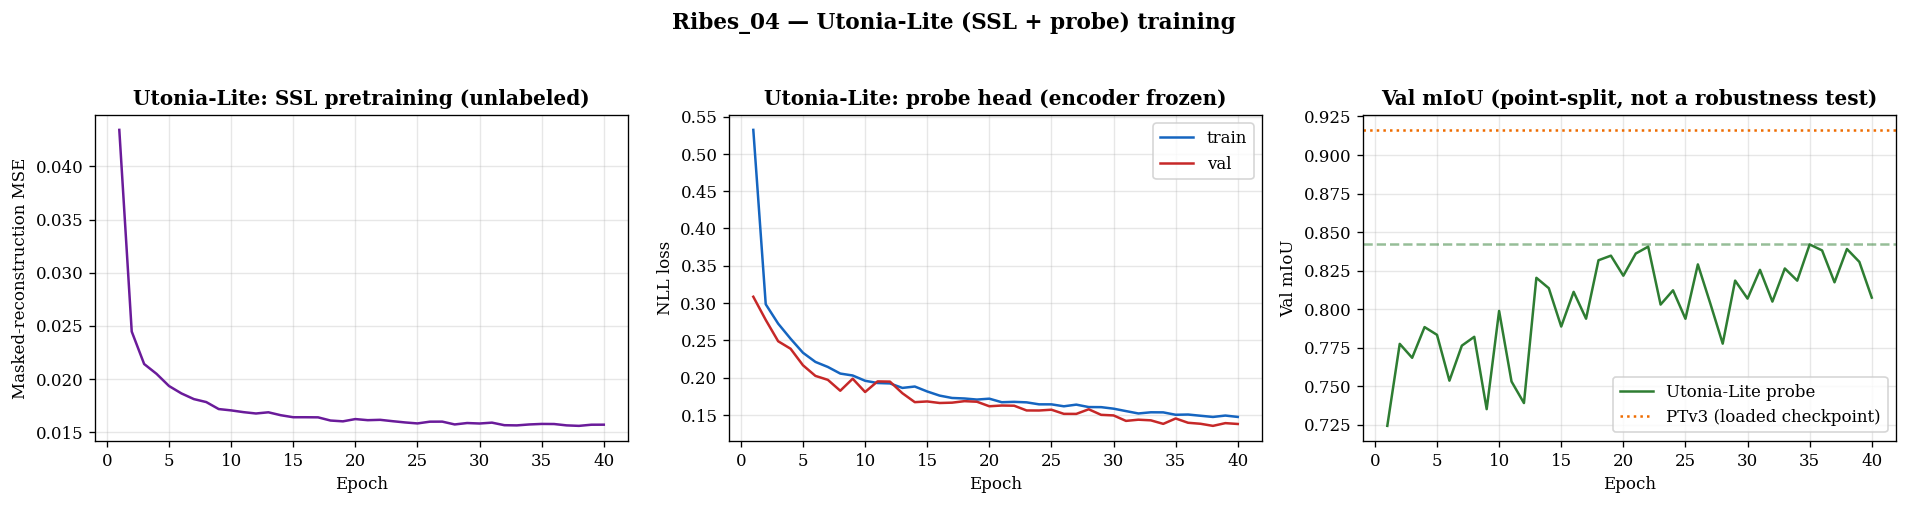

Saved training curves + history CSVs.


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "font.family": "serif", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.bbox": "tight",
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ssl_history["epoch"], ssl_history["recon_loss"], color="#6a1b9a")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Masked-reconstruction MSE")
axes[0].set_title("Utonia-Lite: SSL pretraining (unlabeled)")
axes[0].grid(alpha=0.3)

axes[1].plot(probe_history["epoch"], probe_history["train_loss"], label="train", color="#1565c0")
axes[1].plot(probe_history["epoch"], probe_history["val_loss"], label="val", color="#c62828")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("NLL loss"); axes[1].set_title("Utonia-Lite: probe head (encoder frozen)")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(probe_history["epoch"], probe_history["val_miou"], color="#2e7d32", label="Utonia-Lite probe")
axes[2].axhline(best_val_miou_probe, color="#2e7d32", linestyle="--", alpha=0.5)
if ptv3_history is not None:
    axes[2].plot(ptv3_history["epoch"], ptv3_history["val_miou"], color="#ef6c00", label="PTv3 supervised (fresh)")
    axes[2].axhline(best_val_miou_ptv3, color="#ef6c00", linestyle="--", alpha=0.5)
else:
    axes[2].axhline(ckpt.get("val_miou", np.nan), color="#ef6c00", linestyle=":", label="PTv3 (loaded checkpoint)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val mIoU"); axes[2].set_title("Val mIoU (point-split, not a robustness test)")
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle(f"{PLANT_NAME} — Utonia-Lite (SSL + probe) training", y=1.04, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "00_training_curves.png"))
plt.show()

pd.DataFrame(ssl_history).to_csv(os.path.join(METRICS_DIR, "ssl_pretrain_history.csv"), index=False)
pd.DataFrame(probe_history).to_csv(os.path.join(METRICS_DIR, "probe_train_history.csv"), index=False)
if ptv3_history is not None:
    pd.DataFrame(ptv3_history).to_csv(os.path.join(METRICS_DIR, "ptv3_fallback_train_history.csv"), index=False)
print("Saved training curves + history CSVs.")


## 16. Whole-cloud inference — full-coverage chunked prediction

Identical procedure to the PTv3 notebook, and works unmodified on **either** model since
`PointTransformerV3Lite` and `UtoniaLiteFull` expose the same `forward(xyz_bcn, features_bcn) ->
log-probs` interface.

In [18]:
def predict_full_cloud(model, points_norm, features, n_points=N_POINTS_PER_SAMPLE,
                        n_repeats=N_REPEATS_EVAL, batch_size=BATCH_SIZE, device=DEVICE):
    N = points_norm.shape[0]
    prob_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    count = np.zeros(N, dtype=np.int64)
    feat_full = features if (features is not None and ADDITIONAL_CHANNELS > 0) else None

    model.eval()
    with torch.no_grad():
        for rep in range(n_repeats):
            perm = np.random.default_rng(rep * 97 + 1).permutation(N)
            n_chunks = int(np.ceil(N / n_points))
            chunks = []
            for c in range(n_chunks):
                chunk_idx = perm[c * n_points:(c + 1) * n_points]
                if len(chunk_idx) < n_points:
                    pad_rng = np.random.default_rng(rep * 1000 + c)
                    pad = pad_rng.choice(perm, size=n_points - len(chunk_idx), replace=True)
                    chunk_idx = np.concatenate([chunk_idx, pad])
                chunks.append(chunk_idx)

            for b_start in range(0, len(chunks), batch_size):
                batch_chunks = chunks[b_start:b_start + batch_size]
                batch_idx = np.stack(batch_chunks)                      # [B, n_points]
                pts_b = points_norm[batch_idx]                          # [B, n_points, 3]
                pts_t = torch.from_numpy(pts_b.astype(np.float32)).permute(0, 2, 1).to(device)
                if feat_full is not None:
                    feat_b = feat_full[batch_idx]
                    feat_t = torch.from_numpy(feat_b.astype(np.float32)).permute(0, 2, 1).to(device)
                else:
                    feat_t = None
                logits = model(pts_t, feat_t)                            # [B, n_points, C] log-probs
                probs = torch.exp(logits).cpu().numpy()
                for bi, chunk_idx in enumerate(batch_chunks):
                    np.add.at(prob_sum, chunk_idx, probs[bi])
                    np.add.at(count, chunk_idx, 1)

    count[count == 0] = 1
    avg_probs = prob_sum / count[:, None]
    preds = np.argmax(avg_probs, axis=1)
    mean_confidence = float(avg_probs.max(axis=1).mean())
    return preds, avg_probs, mean_confidence

print("Whole-cloud inference utility ready (shared by both branches).")


Whole-cloud inference utility ready (shared by both branches).


## 17. Evaluate both models on clean GT

In [19]:
MODELS = {
    "PTv3-Supervised": ptv3_model,
    "Utonia-Lite-Probe": utonia_model,
}

gt_metrics_by_model = {}
for model_name, model in MODELS.items():
    t_start = time.time()
    preds, probs, mean_conf = predict_full_cloud(model, gt_xyz_norm_full, gt_features_full)
    inf_time = time.time() - t_start

    m = compute_metrics(gt_semantic, preds)
    m["mean_confidence"] = mean_conf
    m["inference_time_s"] = inf_time
    m["n_points"] = N_GT
    gt_metrics_by_model[model_name] = m

    print(f"[{model_name:<18}] GT mIoU: {m['miou']:.4f} | overall accuracy: {m['overall_accuracy']:.4f} "
          f"| mean confidence: {mean_conf:.4f} | inference time: {inf_time:.1f}s")
    for c in range(NUM_CLASSES):
        name = SEMANTIC_CLASS_NAMES.get(c, str(c))
        print(f"    class {c} ({name:<26}): IoU={m['iou_per_class'][c]:.4f}  "
              f"P={m['precision_per_class'][c]:.4f}  R={m['recall_per_class'][c]:.4f}  "
              f"F1={m['f1_per_class'][c]:.4f}  n={m['support_per_class'][c]}")

    np.save(os.path.join(CM_DIR, f"GT_confusion_matrix_{model_name}.npy"), m["confusion_matrix"])

GT_MIOU_PTV3   = gt_metrics_by_model["PTv3-Supervised"]["miou"]
GT_MIOU_UTONIA = gt_metrics_by_model["Utonia-Lite-Probe"]["miou"]
print(f"\nGT mIoU gap (PTv3 supervised - Utonia-Lite frozen-probe): {GT_MIOU_PTV3 - GT_MIOU_UTONIA:+.4f}")


[PTv3-Supervised   ] GT mIoU: 0.9232 | overall accuracy: 0.9796 | mean confidence: 0.9708 | inference time: 9.6s
    class 0 (Background / Pot / Soil   ): IoU=nan  P=0.0000  R=0.0000  F1=0.0000  n=0
    class 1 (Stem                      ): IoU=0.8699  P=0.9316  R=0.9293  F1=0.9304  n=174696
    class 2 (Leaf                      ): IoU=0.9764  P=0.9878  R=0.9883  F1=0.9881  n=1015670
[Utonia-Lite-Probe ] GT mIoU: 0.8876 | overall accuracy: 0.9682 | mean confidence: 0.9366 | inference time: 9.2s
    class 0 (Background / Pot / Soil   ): IoU=nan  P=0.0000  R=0.0000  F1=0.0000  n=0
    class 1 (Stem                      ): IoU=0.8120  P=0.8605  R=0.9351  F1=0.8962  n=174696
    class 2 (Leaf                      ): IoU=0.9632  P=0.9887  R=0.9739  F1=0.9812  n=1015670

GT mIoU gap (PTv3 supervised - Utonia-Lite frozen-probe): +0.0356


In [20]:
import json as _json

def metrics_to_json_safe(m):
    out = {}
    for k, v in m.items():
        if isinstance(v, np.ndarray):
            out[k] = v.tolist()
        else:
            out[k] = v
    return out

for model_name, m in gt_metrics_by_model.items():
    safe_name = model_name.replace(" ", "_")
    with open(os.path.join(METRICS_DIR, f"gt_baseline_metrics_{safe_name}.json"), "w") as f:
        _json.dump(metrics_to_json_safe(m), f, indent=2)
print("Saved gt_baseline_metrics_<model>.json for both models.")


Saved gt_baseline_metrics_<model>.json for both models.


## 18. GT baseline comparison figure — confusion matrices + per-class IoU, side by side

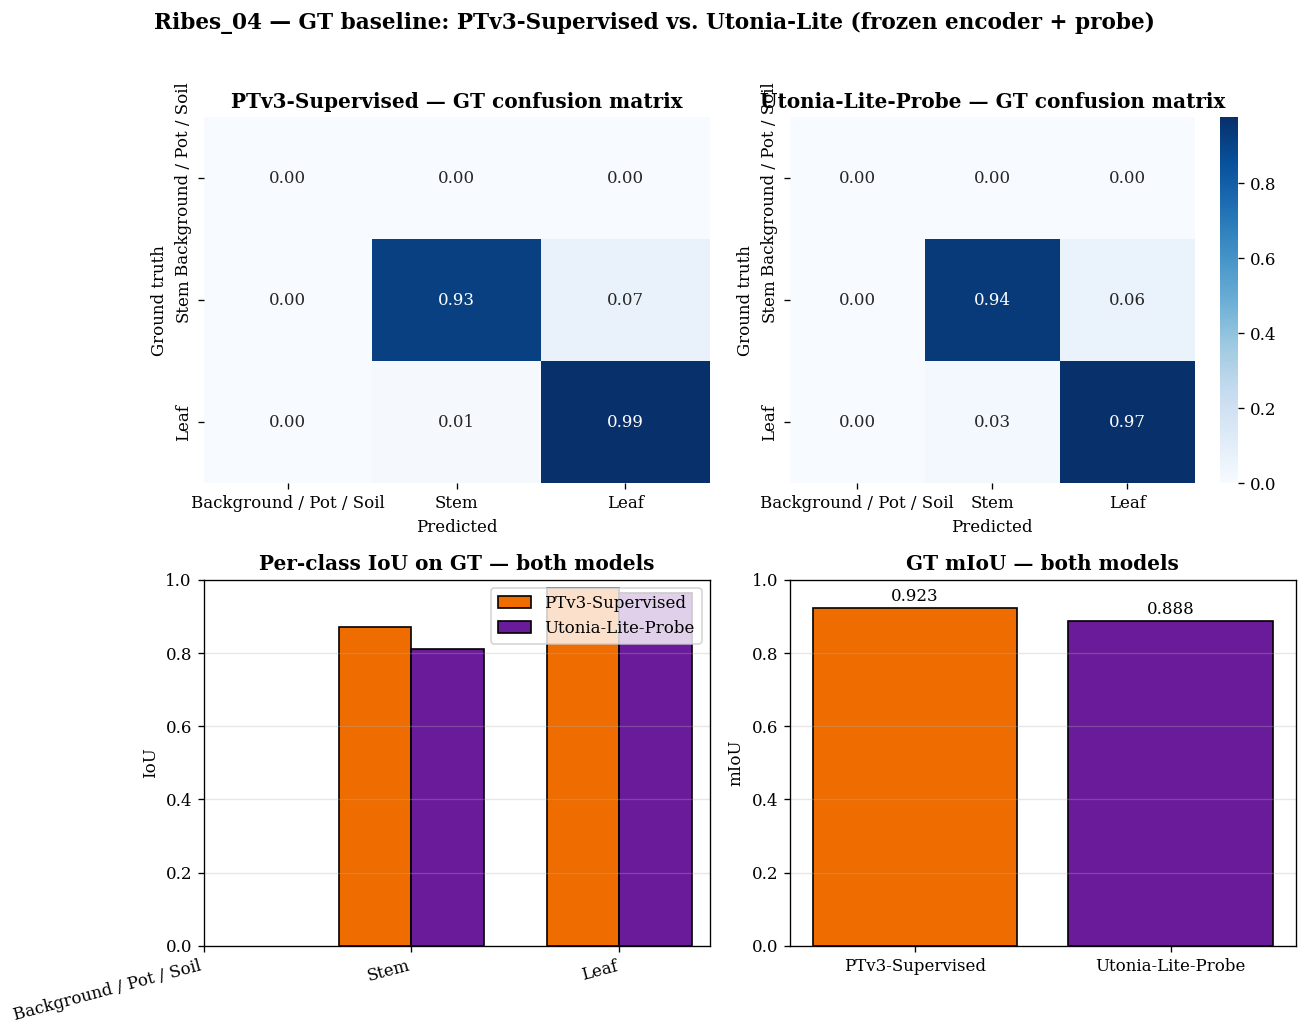

In [21]:
import seaborn as sns

class_names_short = [SEMANTIC_CLASS_NAMES.get(c, str(c)) for c in range(NUM_CLASSES)]
model_names = list(MODELS.keys())
model_colors = {"PTv3-Supervised": "#ef6c00", "Utonia-Lite-Probe": "#6a1b9a"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

for col, model_name in enumerate(model_names):
    m = gt_metrics_by_model[model_name]
    cm_norm = m["confusion_matrix"].astype(float)
    cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=(col == 1),
                xticklabels=class_names_short, yticklabels=class_names_short, ax=axes[0][col])
    axes[0][col].set_xlabel("Predicted"); axes[0][col].set_ylabel("Ground truth")
    axes[0][col].set_title(f"{model_name} — GT confusion matrix")

# Grouped per-class IoU bar chart, both models side by side
x = np.arange(NUM_CLASSES)
width = 0.35
for i, model_name in enumerate(model_names):
    m = gt_metrics_by_model[model_name]
    offset = (i - 0.5) * width
    axes[1][0].bar(x + offset, m["iou_per_class"], width, label=model_name, color=model_colors[model_name], edgecolor="black")
axes[1][0].set_xticks(x); axes[1][0].set_xticklabels(class_names_short, rotation=15, ha="right")
axes[1][0].set_ylabel("IoU"); axes[1][0].set_ylim(0, 1); axes[1][0].set_title("Per-class IoU on GT — both models")
axes[1][0].legend(); axes[1][0].grid(alpha=0.3, axis="y")

axes[1][1].bar(model_names, [gt_metrics_by_model[m]["miou"] for m in model_names],
               color=[model_colors[m] for m in model_names], edgecolor="black")
axes[1][1].set_ylabel("mIoU"); axes[1][1].set_ylim(0, 1); axes[1][1].set_title("GT mIoU — both models")
for i, mn in enumerate(model_names):
    axes[1][1].text(i, gt_metrics_by_model[mn]["miou"] + 0.02, f"{gt_metrics_by_model[mn]['miou']:.3f}", ha="center")
axes[1][1].grid(alpha=0.3, axis="y")

fig.suptitle(f"{PLANT_NAME} — GT baseline: PTv3-Supervised vs. Utonia-Lite (frozen encoder + probe)",
             y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_gt_baseline_comparison.png"))
plt.show()


## 19. Evaluate both models on every noisy variant listed in `manifest.csv`

Same frozen models, same `predict_full_cloud` procedure, applied to every `(category, level)` folder
produced by the Degradation Pipeline notebook — no COLMAP involved, exactly as in the PTv3 notebook. If
a COLMAP-based reconstruction is ever added as its own manifest category, this loop needs no changes.

In [22]:
manifest_df = pd.read_csv(MANIFEST_PATH)
print(f"{len(manifest_df)} noisy variants found in manifest:\n")
print(manifest_df[["category", "level", "n_points", "pct_of_clean"]].to_string(index=False))


21 noisy variants found in manifest:

        category        level  n_points  pct_of_clean
         density          100   1190366        100.00
         density           75    892774         75.00
         density           50    595183         50.00
         density           25    297592         25.00
         density           10    119037         10.00
coordinate_noise          low   1190366        100.00
coordinate_noise       medium   1190366        100.00
coordinate_noise         high   1190366        100.00
  missing_points           10   1071329         90.00
  missing_points           30    833256         70.00
  missing_points           50    595183         50.00
 missing_regions        small   1093706         91.88
 missing_regions       medium    908392         76.31
 missing_regions        large    509112         42.77
  uneven_density         mild    993001         83.42
  uneven_density     moderate    742811         62.40
  uneven_density       severe    576557     

In [23]:
variant_rows = []
confusion_matrices = {}
for model_name, m in gt_metrics_by_model.items():
    confusion_matrices[f"GT__{model_name}"] = m["confusion_matrix"]

for _, row in manifest_df.iterrows():
    category, level, out_dir = row["category"], row["level"], row["output_dir"]
    v_ply  = os.path.join(out_dir, f"{PLANT_NAME}.ply")
    v_sem  = os.path.join(out_dir, f"{PLANT_NAME}_SemanticLabels.txt")

    v_points, v_rgb = load_point_cloud(v_ply)
    v_semantic = load_label_file(v_sem, dtype=np.int64)
    assert v_points.shape[0] == v_semantic.shape[0], f"Point/label mismatch for {category}/{level}"

    v_xyz_norm = normalize_xyz(v_points)
    v_features = make_features(v_rgb) if v_rgb is not None else (
        np.zeros((v_points.shape[0], 3)) if ADDITIONAL_CHANNELS > 0 else None)

    for model_name, model in MODELS.items():
        t0 = time.time()
        v_preds, v_probs, v_mean_conf = predict_full_cloud(model, v_xyz_norm, v_features)
        inf_time = time.time() - t0

        m = compute_metrics(v_semantic, v_preds)
        gt_miou_this_model = gt_metrics_by_model[model_name]["miou"]
        delta_miou = gt_miou_this_model - m["miou"]
        degradation_pct = 100.0 * delta_miou / gt_miou_this_model if gt_miou_this_model > 0 else np.nan

        variant_key = f"{category}_{level}__{model_name}"
        confusion_matrices[variant_key] = m["confusion_matrix"]
        np.save(os.path.join(CM_DIR, f"{variant_key}_confusion_matrix.npy"), m["confusion_matrix"])

        result = {
            "model": model_name, "category": category, "level": level, "params": row.get("params", ""),
            "n_points": int(v_points.shape[0]), "pct_of_clean": float(row.get("pct_of_clean", np.nan)),
            "gt_miou": gt_miou_this_model, "miou": m["miou"], "delta_miou": delta_miou,
            "degradation_pct": degradation_pct, "overall_accuracy": m["overall_accuracy"],
            "mean_confidence": v_mean_conf, "inference_time_s": inf_time,
        }
        for c in range(NUM_CLASSES):
            cname = SEMANTIC_CLASS_NAMES.get(c, str(c)).replace(" / ", "_").replace(" ", "_")
            result[f"iou_class{c}_{cname}"] = m["iou_per_class"][c]
            result[f"precision_class{c}_{cname}"] = m["precision_per_class"][c]
            result[f"recall_class{c}_{cname}"] = m["recall_per_class"][c]
            result[f"f1_class{c}_{cname}"] = m["f1_per_class"][c]
            result[f"support_class{c}_{cname}"] = int(m["support_per_class"][c])
        variant_rows.append(result)

        print(f"[{model_name:<18} | {category:<16}/{str(level):<12}] mIoU={m['miou']:.4f}  "
              f"ΔmIoU={delta_miou:+.4f}  degradation={degradation_pct:+5.1f}%  ({inf_time:.1f}s)")

variant_df = pd.DataFrame(variant_rows)
print(f"\nEvaluated {len(variant_df)} (model, variant) rows across {len(MODELS)} models "
      f"and {len(manifest_df)} noisy variants.")


[PTv3-Supervised    | density         /100         ] mIoU=0.9232  ΔmIoU=+0.0000  degradation= +0.0%  (9.1s)
[Utonia-Lite-Probe  | density         /100         ] mIoU=0.8876  ΔmIoU=+0.0000  degradation= +0.0%  (9.8s)
[PTv3-Supervised    | density         /75          ] mIoU=0.9228  ΔmIoU=+0.0004  degradation= +0.0%  (7.7s)
[Utonia-Lite-Probe  | density         /75          ] mIoU=0.8868  ΔmIoU=+0.0007  degradation= +0.1%  (6.7s)
[PTv3-Supervised    | density         /50          ] mIoU=0.9224  ΔmIoU=+0.0007  degradation= +0.1%  (5.0s)
[Utonia-Lite-Probe  | density         /50          ] mIoU=0.8874  ΔmIoU=+0.0002  degradation= +0.0%  (4.4s)
[PTv3-Supervised    | density         /25          ] mIoU=0.9233  ΔmIoU=-0.0001  degradation= -0.0%  (2.9s)
[Utonia-Lite-Probe  | density         /25          ] mIoU=0.8845  ΔmIoU=+0.0031  degradation= +0.3%  (2.5s)
[PTv3-Supervised    | density         /10          ] mIoU=0.9238  ΔmIoU=-0.0006  degradation= -0.1%  (0.9s)
[Utonia-Lite-Probe  | densit

In [24]:
variant_df.to_csv(os.path.join(METRICS_DIR, "variant_metrics.csv"), index=False)
with open(os.path.join(METRICS_DIR, "variant_metrics.json"), "w") as f:
    _json.dump(variant_rows, f, indent=2)
print("Saved variant_metrics.csv / variant_metrics.json (both models).")


Saved variant_metrics.csv / variant_metrics.json (both models).


## 20. Summary table — `Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation %`

The exact table for the presentation, one row per `(model, category, level)`, ordered to match the
degradation pipeline's own level ordering, and directly stackable next to `robustness_eval_ptv3/` and
`robustness_eval_dgcnn/`'s own `summary_degradation_table.csv` files.

In [25]:
LEVEL_ORDER = {
    "density": [100, 75, 50, 25, 10],
    "coordinate_noise": ["low", "medium", "high"],
    "missing_points": [10, 30, 50],
    "missing_regions": ["small", "medium", "large"],
    "uneven_density": ["mild", "moderate", "severe"],
    "illumination": ["dark", "bright", "low_contrast", "color_shift"],
}

def level_sort_key(row):
    cat, lvl = row["category"], row["level"]
    order = LEVEL_ORDER.get(cat)
    if order is not None and lvl in order:
        return (cat, order.index(lvl))
    return (cat, str(lvl))

variant_df["_sort_key"] = variant_df.apply(level_sort_key, axis=1)
variant_df = variant_df.sort_values(by=["model", "_sort_key"]).drop(columns=["_sort_key"]).reset_index(drop=True)

summary_df = variant_df[["model", "category", "level", "gt_miou", "miou", "delta_miou", "degradation_pct"]].copy()
summary_df.columns = ["Model", "Category", "Level", "GT mIoU", "Noisy mIoU", "ΔmIoU", "Degradation %"]
summary_df.to_csv(os.path.join(METRICS_DIR, "summary_degradation_table.csv"), index=False)

print(summary_df.to_string(index=False,
      formatters={"GT mIoU": "{:.4f}".format, "Noisy mIoU": "{:.4f}".format,
                  "ΔmIoU": "{:+.4f}".format, "Degradation %": "{:+.2f}".format}))


            Model         Category        Level GT mIoU Noisy mIoU   ΔmIoU Degradation %
  PTv3-Supervised coordinate_noise          low  0.9232     0.9228 +0.0004         +0.04
  PTv3-Supervised coordinate_noise       medium  0.9232     0.9165 +0.0067         +0.73
  PTv3-Supervised coordinate_noise         high  0.9232     0.8966 +0.0265         +2.88
  PTv3-Supervised          density           10  0.9232     0.9238 -0.0006         -0.07
  PTv3-Supervised          density          100  0.9232     0.9232 +0.0000         +0.00
  PTv3-Supervised          density           25  0.9232     0.9233 -0.0001         -0.01
  PTv3-Supervised          density           50  0.9232     0.9224 +0.0007         +0.08
  PTv3-Supervised          density           75  0.9232     0.9228 +0.0004         +0.04
  PTv3-Supervised     illumination         dark  0.9232     0.7676 +0.1556        +16.85
  PTv3-Supervised     illumination       bright  0.9232     0.6439 +0.2793        +30.25
  PTv3-Supervised    

## 21. mIoU vs. severity, per category — one line per model

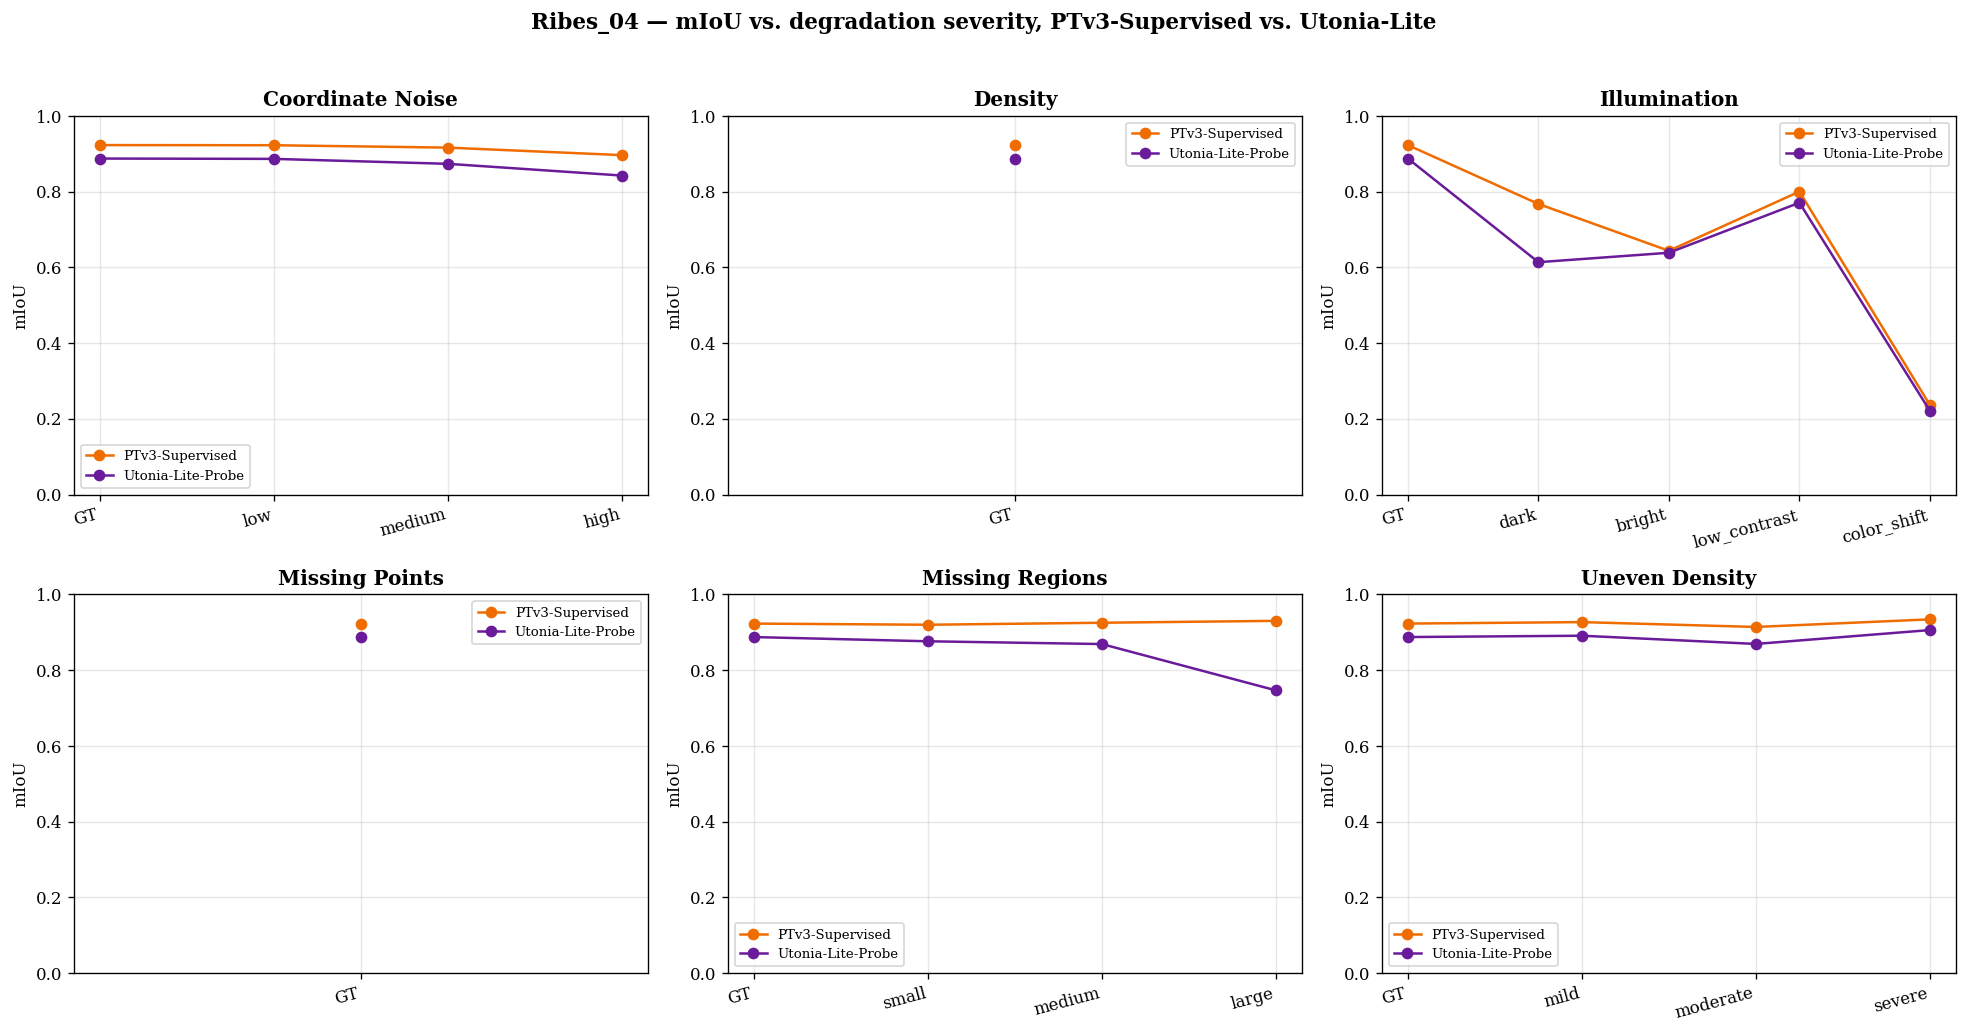

In [26]:
categories = list(dict.fromkeys(variant_df["category"]))
n_cats = len(categories)
n_cols = min(3, n_cats)
n_rows = int(np.ceil(n_cats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows), squeeze=False)

for idx, cat in enumerate(categories):
    ax = axes[idx // n_cols][idx % n_cols]
    for model_name in model_names:
        sub = variant_df[(variant_df["category"] == cat) & (variant_df["model"] == model_name)]
        order = LEVEL_ORDER.get(cat)
        if order is not None:
            sub = sub.set_index("level").reindex([l for l in order if l in sub["level"].values]).reset_index()
        levels = sub["level"].astype(str).tolist()
        miou_vals = sub["miou"].tolist()
        gt_val = gt_metrics_by_model[model_name]["miou"]
        x_labels = ["GT"] + levels
        y_vals = [gt_val] + miou_vals
        ax.plot(x_labels, y_vals, marker="o", color=model_colors[model_name], label=model_name)
    ax.set_title(cat.replace("_", " ").title())
    ax.set_ylabel("mIoU"); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    for tick in ax.get_xticklabels():
        tick.set_rotation(15); tick.set_ha("right")

for j in range(n_cats, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.suptitle(f"{PLANT_NAME} — mIoU vs. degradation severity, PTv3-Supervised vs. Utonia-Lite",
             y=1.02, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_miou_by_category_comparison.png"))
plt.show()


## 22. Degradation-% heatmaps — one per model, same color scale

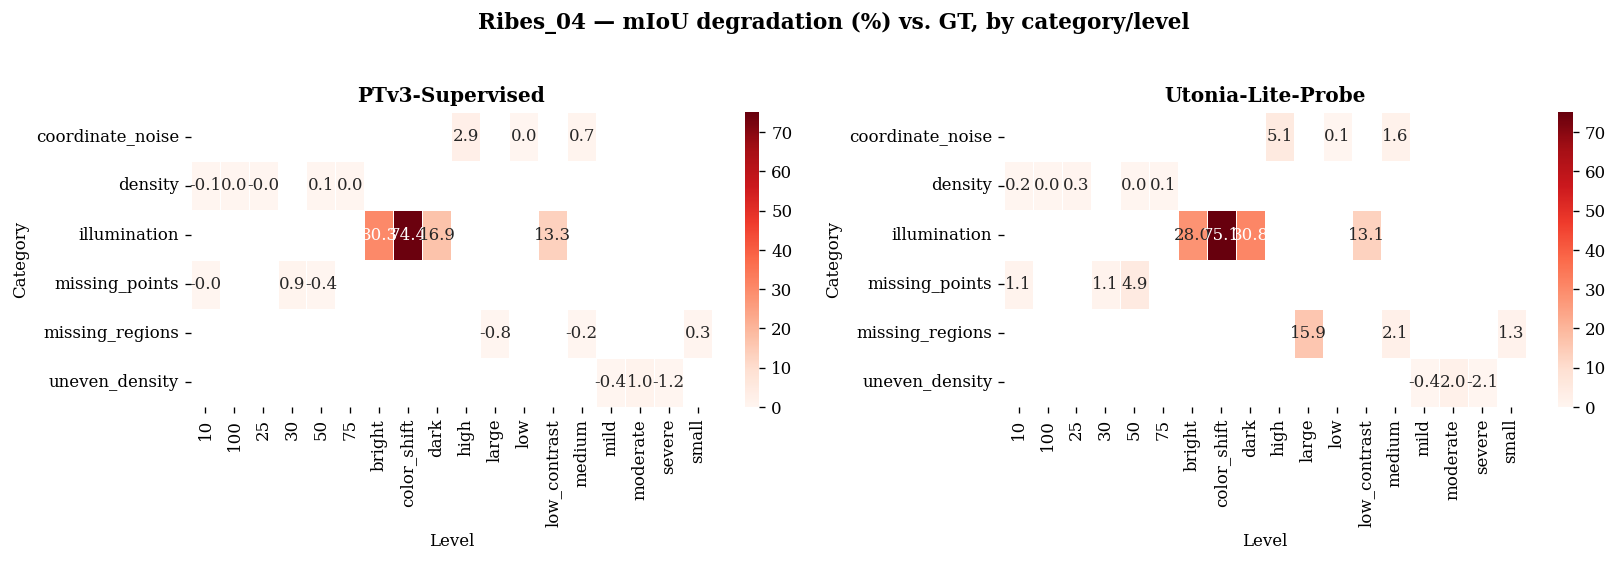

In [27]:
pivot_by_model = {}
for model_name in model_names:
    sub = variant_df[variant_df["model"] == model_name]
    pivot = sub.pivot_table(index="category", columns="level", values="degradation_pct", aggfunc="first")
    pivot_by_model[model_name] = pivot

vmax = max(p.values[~np.isnan(p.values)].max() if p.size and np.isfinite(p.values).any() else 0
           for p in pivot_by_model.values())
vmax = max(vmax, 1.0)

fig, axes = plt.subplots(1, len(model_names), figsize=(7 * len(model_names), 4.5))
if len(model_names) == 1:
    axes = [axes]
for ax, model_name in zip(axes, model_names):
    sns.heatmap(pivot_by_model[model_name], annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=vmax,
                cbar=True, linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Level"); ax.set_ylabel("Category")

fig.suptitle(f"{PLANT_NAME} — mIoU degradation (%) vs. GT, by category/level", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_degradation_pct_heatmap.png"))
plt.show()


## 23. Per-class IoU degradation curves — averaged across all variants, both models

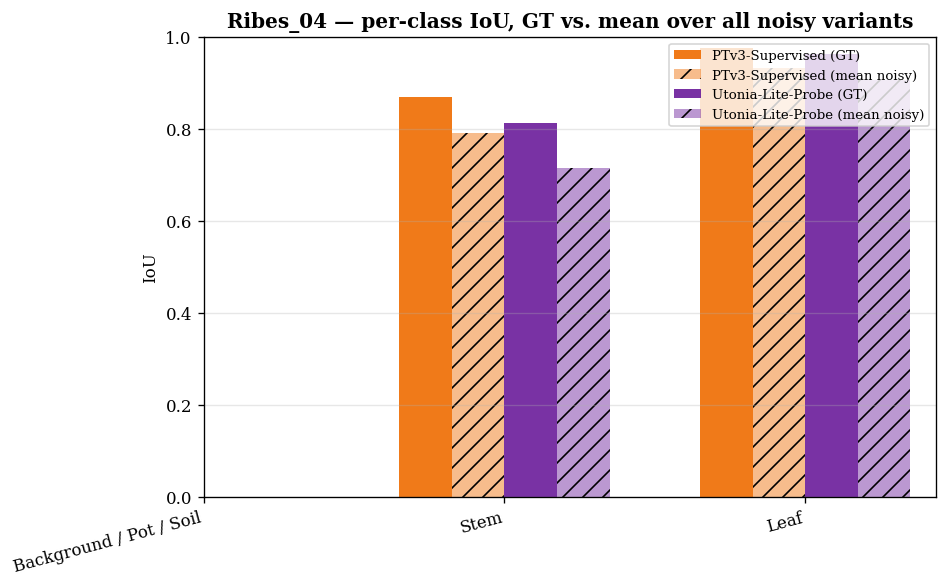

In [28]:
class_iou_cols = [f"iou_class{c}_{SEMANTIC_CLASS_NAMES.get(c, str(c)).replace(' / ', '_').replace(' ', '_')}"
                  for c in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(NUM_CLASSES)
width = 0.35
for i, model_name in enumerate(model_names):
    gt_ious = [gt_metrics_by_model[model_name]["iou_per_class"][c] for c in range(NUM_CLASSES)]
    variant_mean_ious = [variant_df.loc[variant_df["model"] == model_name, col].mean() for col in class_iou_cols]
    offset = (i - 0.5) * width
    ax.bar(x + offset - width / 4, gt_ious, width / 2, color=model_colors[model_name], alpha=0.9,
           label=f"{model_name} — GT" if i == 0 else None, hatch="")
    ax.bar(x + offset + width / 4, variant_mean_ious, width / 2, color=model_colors[model_name], alpha=0.45,
           label=f"{model_name} — mean over noisy variants" if i == 0 else None, hatch="//")

# Simpler, clearer legend built manually
from matplotlib.patches import Patch
legend_handles = []
for model_name in model_names:
    legend_handles.append(Patch(facecolor=model_colors[model_name], alpha=0.9, label=f"{model_name} (GT)"))
    legend_handles.append(Patch(facecolor=model_colors[model_name], alpha=0.45, hatch="//", label=f"{model_name} (mean noisy)"))
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

ax.set_xticks(x); ax.set_xticklabels(class_names_short, rotation=15, ha="right")
ax.set_ylabel("IoU"); ax.set_ylim(0, 1)
ax.set_title(f"{PLANT_NAME} — per-class IoU, GT vs. mean over all noisy variants")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_per_class_iou_degradation.png"))
plt.show()


## 24. Confusion-matrix grid — GT vs. worst variant per category, both models

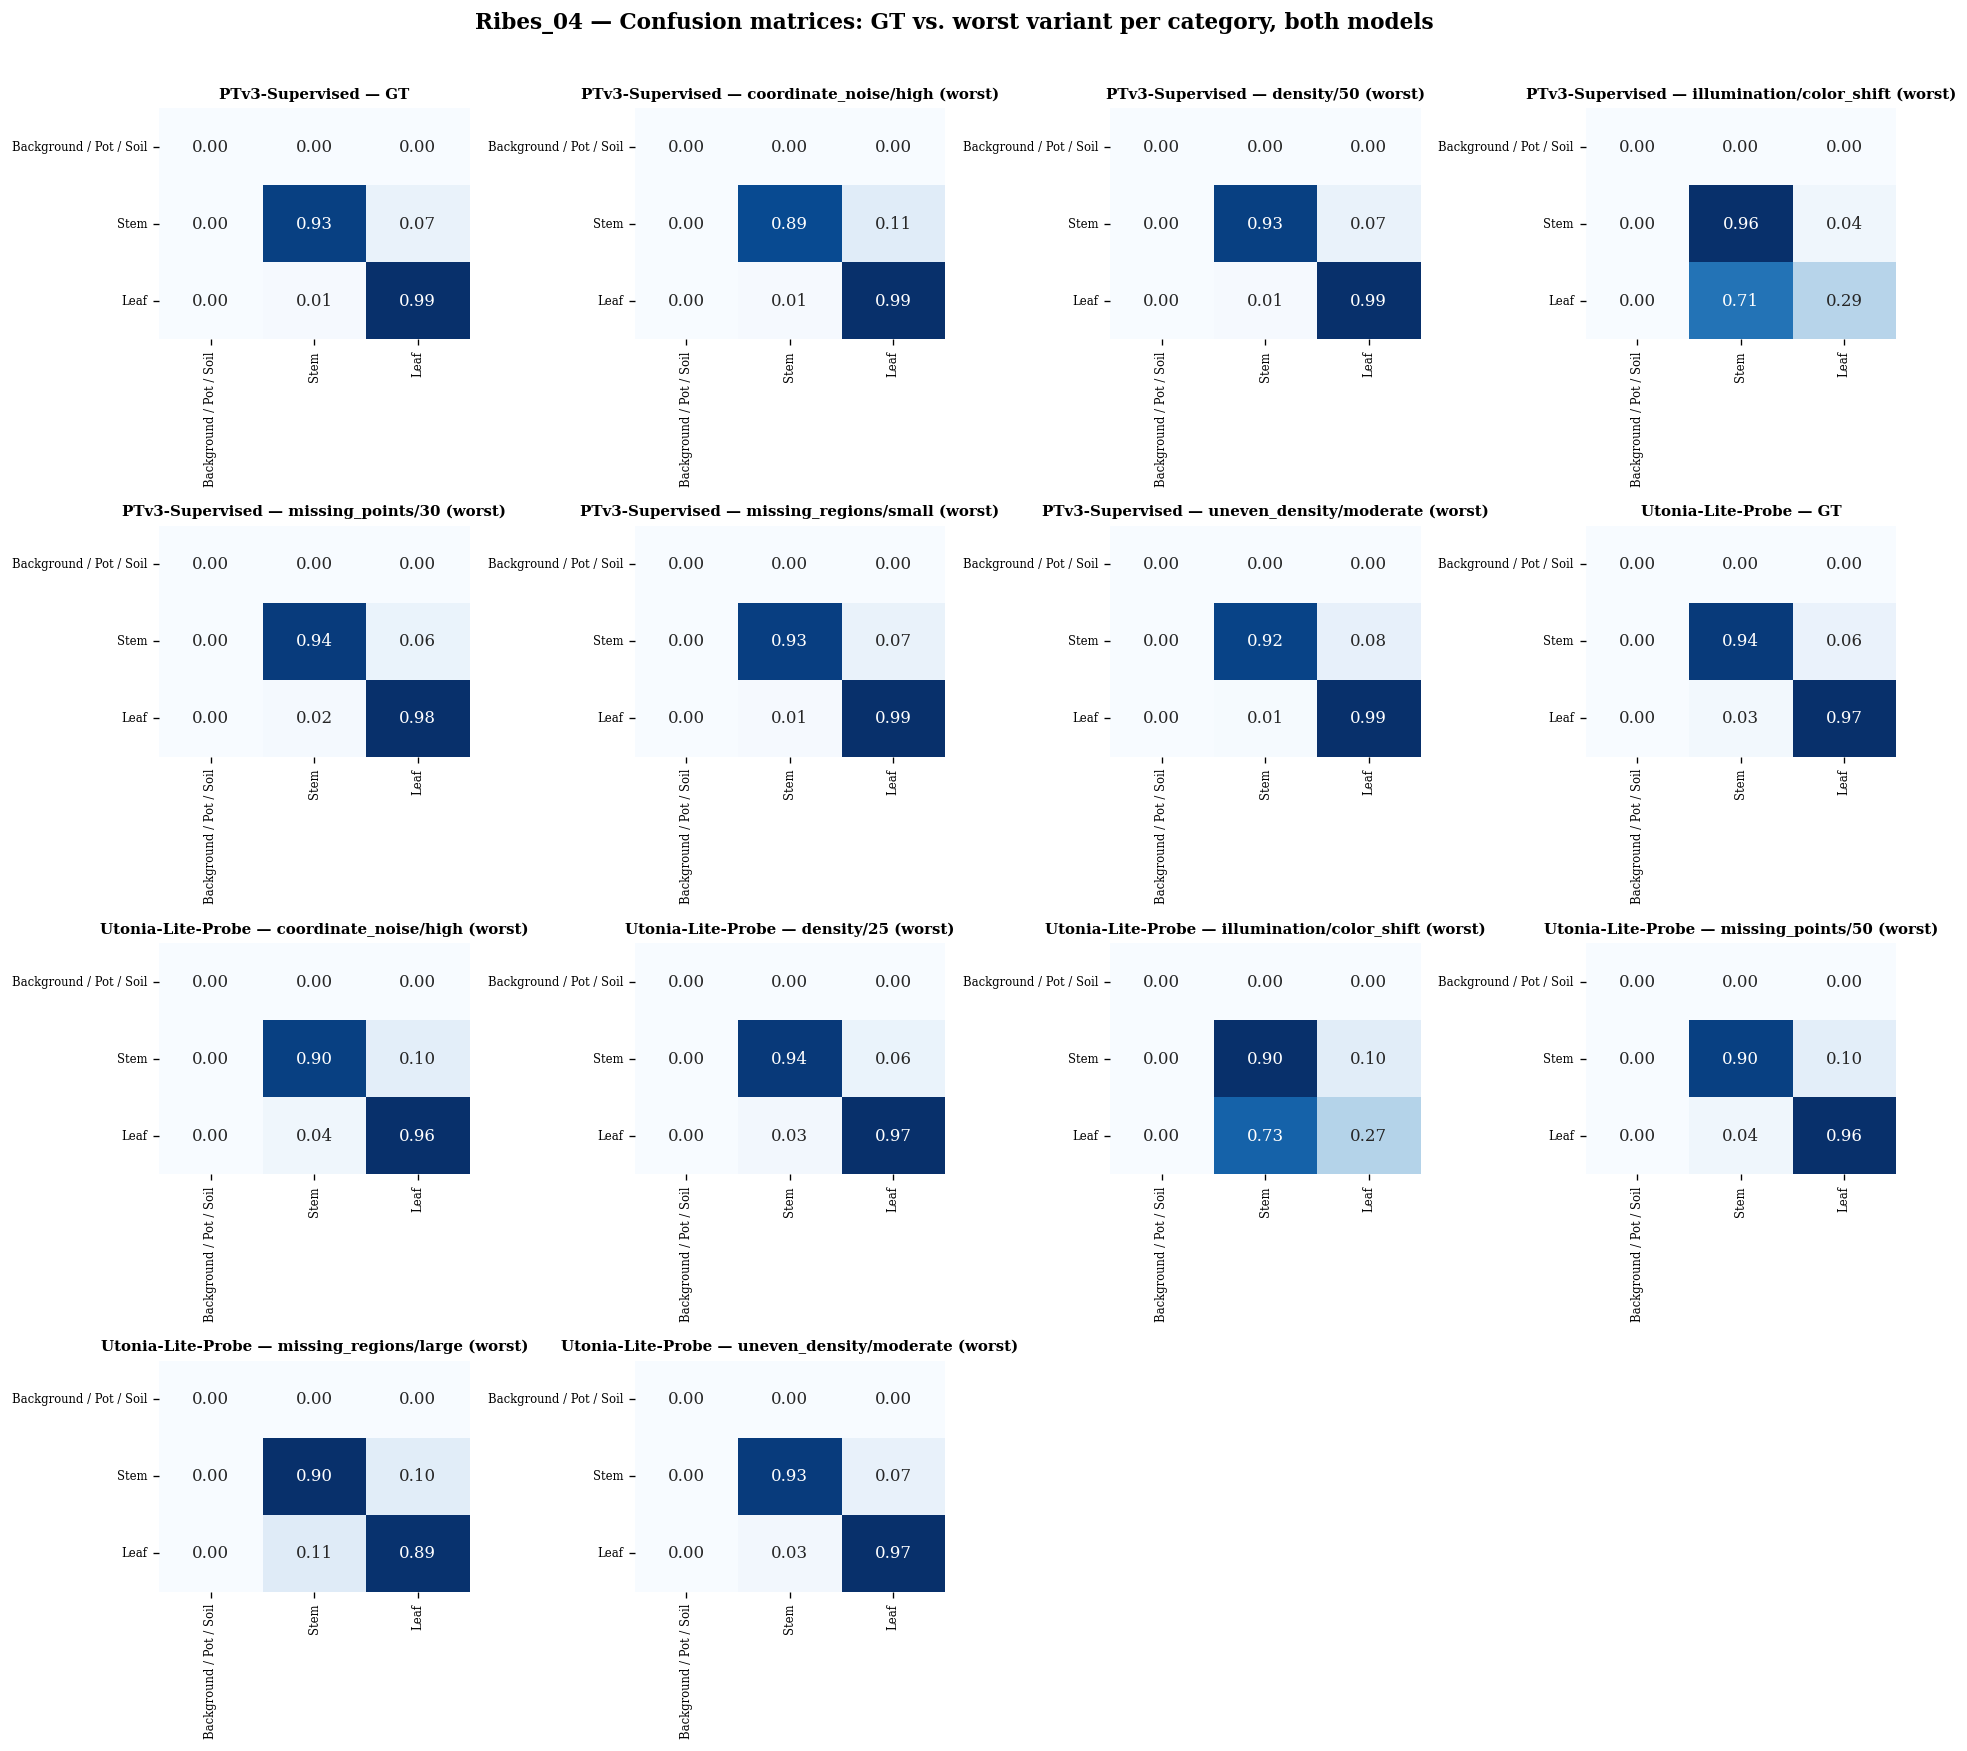

In [29]:
items_cm = []
for model_name in model_names:
    items_cm.append((f"{model_name} — GT", gt_metrics_by_model[model_name]["confusion_matrix"]))
    sub = variant_df[variant_df["model"] == model_name]
    for cat in categories:
        cat_sub = sub[sub["category"] == cat]
        if cat_sub.empty:
            continue
        worst = cat_sub.loc[cat_sub["degradation_pct"].idxmax()]
        key = f"{worst['category']}_{worst['level']}__{model_name}"
        cm = confusion_matrices.get(key)
        if cm is not None:
            items_cm.append((f"{model_name} — {cat}/{worst['level']} (worst)", cm))

n_items = len(items_cm)
n_cols_cm = 4
n_rows_cm = int(np.ceil(n_items / n_cols_cm))
fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(4 * n_cols_cm, 3.6 * n_rows_cm), squeeze=False)

for idx, (name, cm) in enumerate(items_cm):
    ax = axes[idx // n_cols_cm][idx % n_cols_cm]
    cm_n = cm.astype(float)
    cm_n = cm_n / cm_n.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=class_names_short, yticklabels=class_names_short, ax=ax)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(n_items, n_rows_cm * n_cols_cm):
    axes[j // n_cols_cm][j % n_cols_cm].axis("off")

fig.suptitle(f"{PLANT_NAME} — Confusion matrices: GT vs. worst variant per category, both models",
             y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_confusion_matrix_grid.png"))
plt.show()


## 25. Robustness-gap chart — is the frozen self-supervised encoder more or less robust?

The one figure this notebook adds that the PTv3-only notebook can't produce: for each category, the
**degradation %** of the fully-supervised model vs. the frozen-encoder linear probe, and their gap. A
positive gap (`Utonia − PTv3`) means the frozen self-supervised representation degrades *more* under
that kind of noise than the fully fine-tuned model; negative means it's *more* robust.

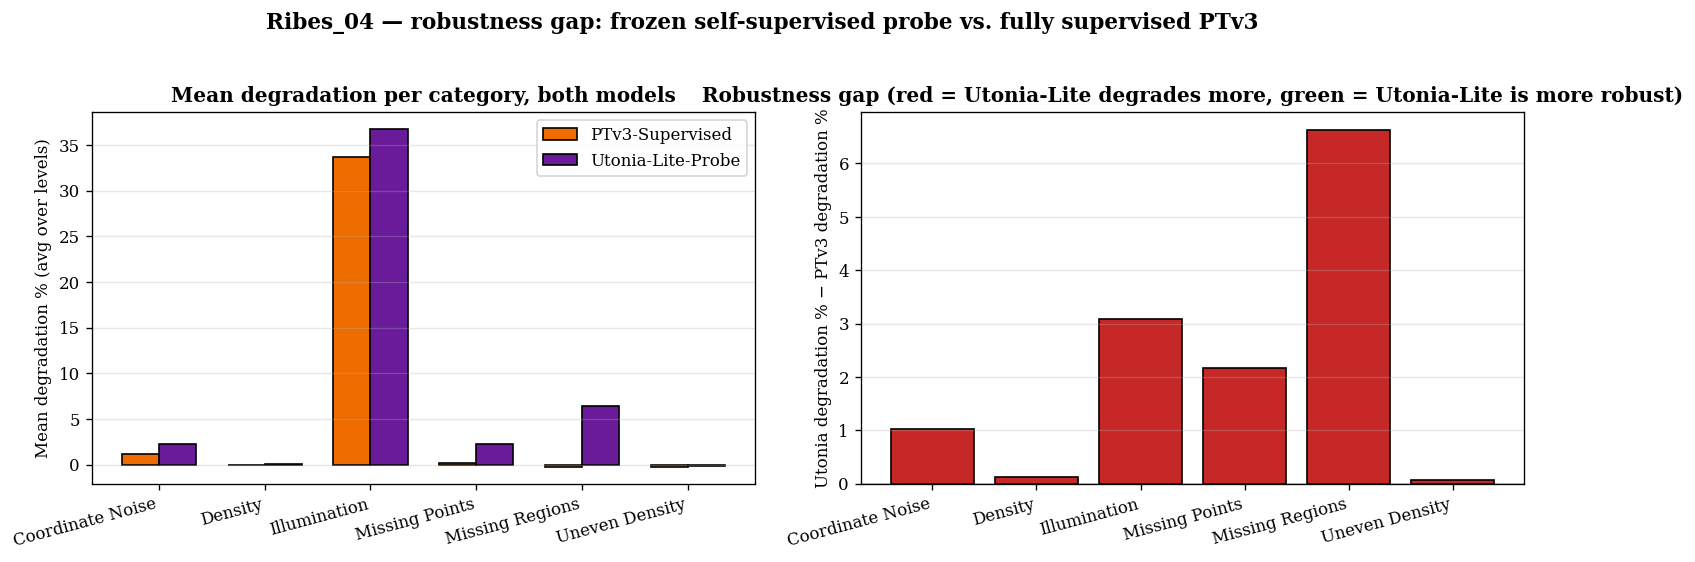

        category  PTv3-Supervised  Utonia-Lite-Probe  gap_utonia_minus_ptv3
coordinate_noise         1.214095           2.239326               1.025231
         density         0.008942           0.138809               0.129867
    illumination        33.694469          36.777523               3.083055
  missing_points         0.165732           2.329824               2.164092
 missing_regions        -0.228461           6.403843               6.632304
  uneven_density        -0.220105          -0.141281               0.078824


In [30]:
gap_rows = []
for cat in categories:
    ptv3_deg = variant_df[(variant_df["category"] == cat) & (variant_df["model"] == "PTv3-Supervised")]["degradation_pct"].mean()
    utonia_deg = variant_df[(variant_df["category"] == cat) & (variant_df["model"] == "Utonia-Lite-Probe")]["degradation_pct"].mean()
    gap_rows.append({"category": cat, "PTv3-Supervised": ptv3_deg, "Utonia-Lite-Probe": utonia_deg,
                      "gap_utonia_minus_ptv3": utonia_deg - ptv3_deg})
gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(os.path.join(METRICS_DIR, "robustness_gap_by_category.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(categories))
width = 0.35
axes[0].bar(x - width / 2, gap_df["PTv3-Supervised"], width, label="PTv3-Supervised", color=model_colors["PTv3-Supervised"], edgecolor="black")
axes[0].bar(x + width / 2, gap_df["Utonia-Lite-Probe"], width, label="Utonia-Lite-Probe", color=model_colors["Utonia-Lite-Probe"], edgecolor="black")
axes[0].set_xticks(x); axes[0].set_xticklabels([c.replace("_", " ").title() for c in categories], rotation=15, ha="right")
axes[0].set_ylabel("Mean degradation % (avg over levels)")
axes[0].set_title("Mean degradation per category, both models")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

colors_gap = ["#c62828" if g > 0 else "#2e7d32" for g in gap_df["gap_utonia_minus_ptv3"]]
axes[1].bar(x, gap_df["gap_utonia_minus_ptv3"], color=colors_gap, edgecolor="black")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels([c.replace("_", " ").title() for c in categories], rotation=15, ha="right")
axes[1].set_ylabel("Utonia degradation % − PTv3 degradation %")
axes[1].set_title("Robustness gap (red = Utonia-Lite degrades more, green = Utonia-Lite is more robust)")
axes[1].grid(alpha=0.3, axis="y")

fig.suptitle(f"{PLANT_NAME} — robustness gap: frozen self-supervised probe vs. fully supervised PTv3",
             y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_robustness_gap.png"))
plt.show()

print(gap_df.to_string(index=False))


## 26. Auto-generated Markdown report

In [31]:
report_path = os.path.join(REPORT_DIR, "utonia_vs_ptv3_report.md")

lines = []
lines.append(f"# Utonia-Lite (frozen SSL encoder) vs. Point Transformer V3 (supervised) — {PLANT_NAME}\n")
lines.append(f"- GT points: **{N_GT:,}**")
lines.append(f"- PTv3-Supervised: {n_params_ptv3:,} parameters, "
             f"{'loaded from existing checkpoint' if ptv3_history is None else f'trained fresh for {EPOCHS} epochs'}, "
             f"GT mIoU = **{GT_MIOU_PTV3:.4f}**")
lines.append(f"- Utonia-Lite: {n_params_encoder:,} encoder parameters (frozen, SSL-pretrained for {SSL_EPOCHS} epochs, "
             f"mask ratio {SSL_MASK_RATIO}) + {n_params_probe:,} probe parameters (trained for {PROBE_EPOCHS} epochs), "
             f"GT mIoU = **{GT_MIOU_UTONIA:.4f}**")
lines.append(f"- GT mIoU gap (PTv3 − Utonia-Lite): **{GT_MIOU_PTV3 - GT_MIOU_UTONIA:+.4f}**\n")

lines.append("## Per-class IoU — GT baseline, both models\n")
lines.append("| Class | PTv3 IoU | Utonia-Lite IoU |")
lines.append("|---|---:|---:|")
for c in range(NUM_CLASSES):
    name = SEMANTIC_CLASS_NAMES.get(c, str(c))
    lines.append(f"| {name} | {gt_metrics_by_model['PTv3-Supervised']['iou_per_class'][c]:.4f} | "
                 f"{gt_metrics_by_model['Utonia-Lite-Probe']['iou_per_class'][c]:.4f} |")

lines.append("\n## Degradation summary — Model / Category / Level / GT mIoU / Noisy mIoU / ΔmIoU / Degradation %\n")
lines.append("| Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation % |")
lines.append("|---|---|---|---:|---:|---:|---:|")
for _, r in summary_df.iterrows():
    lines.append(f"| {r['Model']} | {r['Category']} | {r['Level']} | {r['GT mIoU']:.4f} | "
                 f"{r['Noisy mIoU']:.4f} | {r['ΔmIoU']:.4f} | {r['Degradation %']:.2f}% |")

lines.append("\n## Robustness gap by category (mean degradation %, Utonia-Lite − PTv3)\n")
lines.append("| Category | PTv3 mean degradation % | Utonia-Lite mean degradation % | Gap |")
lines.append("|---|---:|---:|---:|")
for _, r in gap_df.iterrows():
    lines.append(f"| {r['category']} | {r['PTv3-Supervised']:.2f}% | {r['Utonia-Lite-Probe']:.2f}% | "
                 f"{r['gap_utonia_minus_ptv3']:+.2f} |")

more_robust = "Utonia-Lite (frozen probe)" if gap_df["gap_utonia_minus_ptv3"].mean() < 0 else "PTv3-Supervised"
lines.append(f"\n**Overall, `{more_robust}` shows lower mean degradation across categories.** "
             f"Read this alongside the GT mIoU gap above — a frozen encoder that starts from a lower "
             f"GT mIoU can still look artificially 'robust' simply by having less headroom to lose; "
             f"the mIoU-vs-severity figure (Section 21) shows the absolute curves, not just the relative drop.\n")

lines.append("## Most / least robust (variant, model) pair\n")
worst_row = variant_df.loc[variant_df["degradation_pct"].idxmax()]
best_row = variant_df.loc[variant_df["degradation_pct"].idxmin()]
lines.append(f"- **Most degrading**: `{worst_row['model']}` on `{worst_row['category']}/{worst_row['level']}` "
             f"(mIoU {worst_row['miou']:.4f}, {worst_row['degradation_pct']:+.1f}%)")
lines.append(f"- **Least degrading**: `{best_row['model']}` on `{best_row['category']}/{best_row['level']}` "
             f"(mIoU {best_row['miou']:.4f}, {best_row['degradation_pct']:+.1f}%)")

lines.append("\n## Figures\n")
lines.append("- `figures/00_training_curves.png`")
lines.append("- `figures/01_gt_baseline_comparison.png`")
lines.append("- `figures/02_miou_by_category_comparison.png`")
lines.append("- `figures/03_degradation_pct_heatmap.png`")
lines.append("- `figures/04_per_class_iou_degradation.png`")
lines.append("- `figures/05_confusion_matrix_grid.png`")
lines.append("- `figures/06_robustness_gap.png`")

lines.append("\n## Scope notes\n")
lines.append("- No COLMAP reconstructions were involved — GT vs. `noisy_reconstruction/degraded/` "
             "variants only, same scope as the sibling PTv3 notebook.")
lines.append("- Utonia-Lite is a local, single-domain, pure-PyTorch reimplementation of Utonia's masked "
             "self-supervised pretraining + frozen-encoder linear probing recipe — **not** the official "
             "137M-parameter cross-domain checkpoint, which requires the Pointcept/spconv/flash-attn stack.")

with open(report_path, "w") as f:
    f.write("\n".join(lines))

print(f"Report saved to: {report_path}")
print("\n".join(lines[:24]))


Report saved to: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/Ribes_04/utonia/report/utonia_vs_ptv3_report.md
# Utonia-Lite (frozen SSL encoder) vs. Point Transformer V3 (supervised) — Ribes_04

- GT points: **1,190,366**
- PTv3-Supervised: 6,465,155 parameters, loaded from existing checkpoint, GT mIoU = **0.9232**
- Utonia-Lite: 6,118,022 encoder parameters (frozen, SSL-pretrained for 40 epochs, mask ratio 0.3) + 347,139 probe parameters (trained for 40 epochs), GT mIoU = **0.8876**
- GT mIoU gap (PTv3 − Utonia-Lite): **+0.0356**

## Per-class IoU — GT baseline, both models

| Class | PTv3 IoU | Utonia-Lite IoU |
|---|---:|---:|
| Background / Pot / Soil | nan | nan |
| Stem | 0.8699 | 0.8120 |
| Leaf | 0.9764 | 0.9632 |

## Degradation summary — Model / Category / Level / GT mIoU / Noisy mIoU / ΔmIoU / Degradation %

| Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation % |
|---|---|---|---:|---:|---:|---:|
| PTv3-Supervised | coordinate_noise | l

## ✅ Done

```
outputs/Ribes_04/utonia/
├── checkpoints/
│   ├── ptv3_supervised.pth          <- copy of the loaded checkpoint, or a freshly trained fallback
│   ├── utonia_lite_encoder.pth      <- frozen, SSL-pretrained encoder
│   └── utonia_lite_probe.pth        <- trained segmentation probe head (best val mIoU)
├── tables/
│   ├── ssl_pretrain_history.csv
│   ├── probe_train_history.csv
│   ├── ptv3_fallback_train_history.csv        (only written if no existing checkpoint was found)
│   ├── gt_baseline_metrics_PTv3-Supervised.json
│   ├── gt_baseline_metrics_Utonia-Lite-Probe.json
│   ├── variant_metrics.csv / .json            <- both models, one row per (model, category, level)
│   ├── summary_degradation_table.csv          <- Model | Category | Level | GT mIoU | Noisy mIoU | ΔmIoU | Degradation %
│   ├── robustness_gap_by_category.csv
│   └── confusion_matrices/
│       ├── GT_confusion_matrix_<model>.npy
│       └── <category>_<level>__<model>_confusion_matrix.npy
├── figures/
│   ├── 00_training_curves.png
│   ├── 01_gt_baseline_comparison.png
│   ├── 02_miou_by_category_comparison.png
│   ├── 03_degradation_pct_heatmap.png
│   ├── 04_per_class_iou_degradation.png
│   ├── 05_confusion_matrix_grid.png
│   └── 06_robustness_gap.png
└── report/
    └── utonia_vs_ptv3_report.md
```

No `.ply` files are written anywhere by this notebook — only metrics (`.csv` / `.json` / `.npy`),
figures (`.png`), the checkpoints, and the Markdown report.

**To re-run for another plant:** change `PLANT_NAME` in Section 2 (make sure that plant's
`gt_reconstruction/`, `noisy_reconstruction/degraded/.../manifest.csv`, and (ideally)
`robustness_eval_ptv3/checkpoints/ptv3_best.pth` already exist).

**To compare against PointNet++ / DGCNN / PointGroup / SoftGroup:** this notebook writes to its own
`utonia/` folder, so every model's `summary_degradation_table.csv` can be concatenated without
overwriting anything.

**If you later get the real Utonia weights working** (Pointcept + spconv + flash-attn, on a runtime that
can actually build them): the cleanest drop-in point is Section 8 — swap `UtoniaEncoderLite`'s
`forward()` internals for a call into the real pretrained encoder, keep its output shaped as the same
`feats` dict `UtoniaDecoderHead` expects, and everything from Section 14 onward (probe training,
evaluation, figures, report) runs unchanged.
